# Comprehensive Econometric and Information-Theoretic Analysis
## *From Tweets to Trades: Analysing Sentiment Signal and Information Network for Crypto Market Prediction*

This notebook is the all-inclusive empirical analysis pipeline for the dissertation. It moves through three logically connected stages:

**Stage 1 — Optimal Specification Selection (Sections 1–4)**
Loads the data, builds panels at daily, weekly, and monthly resolution, runs stationarity diagnostics, and chooses the optimal lag for each panel using information criteria (AIC and BIC). The chosen lag then drives every test in Stage 2.

**Stage 2 — Within-Asset Causality (Sections 5–9)**
For every (platform, asset, frequency) combination, runs the principled set of econometric tests at the pre-selected optimal lag: contemporaneous correlation, lead-lag cross-correlation, Granger causality (sentiment to returns and returns to sentiment), Vector Autoregression with Impulse Response Functions, and the returns-on-returns autoregression that establishes the momentum/mean-reversion baseline. Multi-lag scans are preserved as appendix-style robustness checks.

**Stage 3 — Cross-Asset Transfer Entropy and Information Networks (Sections 10–12)**
This is the new methodological contribution. Computes non-parametric transfer entropy between every pair of (asset, variable) combinations within each platform, building four directed networks per platform: Price→Price, Sentiment→Sentiment, Sentiment→Price, and Price→Sentiment. Significance is established through shuffled-data Z-scores. The resulting networks are visualised, summarised, and analysed for community structure. This directly answers the *information network* half of the dissertation title.

**Stage 4 — Synthesis and Export (Section 13)**
Consolidates all results into one Excel workbook and packages all plots and tables for download.

---

**Outputs produced:**
- One time-series dual-axis plot per (platform, asset).
- ADF stationarity tables.
- Optimal lag selection table.
- Pearson and Spearman correlation tables at all frequencies.
- Lead-lag cross-correlation plots and tables.
- Granger causality results at the principled optimal lag, plus full multi-lag scans for the appendix.
- VAR fits with Impulse Response Function plots.
- Returns-on-returns AR(p) tables.
- Transfer entropy matrices and Z-score matrices for every platform.
- Directed network visualisations of the four causality networks per platform.
- Community detection results.
- A consolidated master workbook tying everything together for the dissertation.

## 0. Setup

In [1]:
!pip install -q pandas numpy matplotlib seaborn statsmodels scipy openpyxl networkx python-louvain pyinform

import os
import warnings
import shutil
import json
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from scipy import stats
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg
from google.colab import files

try:
    import community as community_louvain
    HAS_LOUVAIN = True
except ImportError:
    HAS_LOUVAIN = False
    print('python-louvain not available, community detection will be skipped.')

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

os.makedirs('data/market', exist_ok=True)
os.makedirs('data/sentiment', exist_ok=True)
os.makedirs('results/plots', exist_ok=True)
os.makedirs('results/tables', exist_ok=True)
os.makedirs('results/networks', exist_ok=True)

np.random.seed(42)
print('Setup complete. All dependencies loaded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 1.1 MB/s eta 0:00:00
Setup complete. All dependencies loaded.


## 1. Upload Data Files

Upload the sentiment workbook (e.g. `sentiment_daily_panel.xlsx`) plus all per-asset market CSVs.

In [3]:
print('Upload the sentiment workbook plus all per-asset market data CSVs:\n')
uploaded = files.upload()
for fname, content in uploaded.items():
    dest = f'data/sentiment/{fname}' if fname.endswith('.xlsx') else f'data/market/{fname}'
    with open(dest, 'wb') as f:
        f.write(content)
    print(f'  Saved: {dest} ({len(content)/1e6:.2f} MB)')

Upload the sentiment workbook plus all per-asset market data CSVs:



Saving bitcoin_daily_cleaned.csv to bitcoin_daily_cleaned.csv
Saving dogecoin_daily_cleaned.csv to dogecoin_daily_cleaned.csv
Saving ethereum_daily_cleaned.csv to ethereum_daily_cleaned.csv
Saving shiba_inu_daily_cleaned.csv to shiba_inu_daily_cleaned.csv
Saving tether_daily_cleaned.csv to tether_daily_cleaned.csv
  Saved: data/market/bitcoin_daily_cleaned.csv (0.43 MB)
  Saved: data/market/dogecoin_daily_cleaned.csv (0.43 MB)
  Saved: data/market/ethereum_daily_cleaned.csv (0.42 MB)
  Saved: data/market/shiba_inu_daily_cleaned.csv (0.32 MB)
  Saved: data/market/tether_daily_cleaned.csv (0.39 MB)


## 2. Load Data and Build Multi-Frequency Panels

**What this section does:** Reads the sentiment workbook (one sheet per platform-asset combination) and the per-asset market CSVs, then merges them on date to produce three panels per platform-asset combination: daily, weekly, and monthly.

**Aggregation logic for non-daily panels:**
- **Sentiment:** post-count weighted mean across the period (so a week with 200 posts contributes more weight than a week with 5 posts).
- **Price:** end-of-period value (last observed price within the period).
- **Log return:** sum of daily log returns (compound additively, which is the correct way to compound log returns).
- **Volume:** sum across the period.
- **Volatility:** mean across the period.

**Special case for news:** ProQuest news sentiment is collected month-by-month, so the underlying observations are inherently monthly. For news panels, only the monthly panel is built. Building daily/weekly news panels would require forward-filling, which inflates apparent statistical power without adding real information.

In [4]:
# --- Load sentiment workbook ---
sentiment_files = [f for f in os.listdir('data/sentiment') if f.endswith('.xlsx')]
if not sentiment_files:
    raise FileNotFoundError('No .xlsx file in data/sentiment/')
sentiment_path = f'data/sentiment/{sentiment_files[0]}'
xl = pd.ExcelFile(sentiment_path)
sentiment_sheets = [s for s in xl.sheet_names if not s.startswith('_')]

sentiment_panels = {}
for sheet in sentiment_sheets:
    df = pd.read_excel(xl, sheet_name=sheet)
    df['date'] = pd.to_datetime(df['date'])
    sentiment_panels[sheet] = df

# --- Load market data ---
market_panels = {}
for fname in os.listdir('data/market'):
    if not fname.endswith('.csv'):
        continue
    df = pd.read_csv(f'data/market/{fname}')
    df['date'] = pd.to_datetime(df['date'])
    asset = df['asset'].iloc[0] if 'asset' in df.columns else fname.split('_')[0]
    market_panels[asset] = df

print(f'Sentiment panels loaded: {len(sentiment_panels)}')
for k, v in sentiment_panels.items():
    print(f'  {k:25s} {len(v):>5,} rows  ({v["date"].min().date()} to {v["date"].max().date()})')
print(f'\nMarket panels loaded: {len(market_panels)}')
for k, v in market_panels.items():
    print(f'  {k:25s} {len(v):>5,} rows')

Sentiment panels loaded: 13
  bluesky_bitcoin             607 rows  (2023-03-01 to 2024-12-30)
  bluesky_crypto_general      617 rows  (2023-03-06 to 2024-12-30)
  bluesky_dogecoin            534 rows  (2023-03-07 to 2024-12-30)
  bluesky_ethereum            583 rows  (2023-03-03 to 2024-12-30)
  bluesky_shiba_inu           511 rows  (2023-04-03 to 2024-12-30)
  reddit_bitcoin              846 rows  (2020-01-01 to 2024-12-29)
  reddit_dogecoin             817 rows  (2020-01-01 to 2024-12-13)
  reddit_ethereum             533 rows  (2020-01-01 to 2024-12-12)
  reddit_shiba_inu            892 rows  (2020-08-03 to 2024-12-28)
  news_bitcoin                 59 rows  (2020-01-01 to 2024-12-01)
  news_dogecoin                52 rows  (2020-06-01 to 2024-12-01)
  news_ethereum                60 rows  (2020-01-01 to 2024-12-01)
  news_shiba_inu               44 rows  (2021-05-01 to 2024-12-01)

Market panels loaded: 5
  bitcoin                   1,827 rows
  dogecoin                  1,827 row

In [5]:
def merge_daily(sent_df, market_df):
    """Merge sentiment and market data on date at daily resolution."""
    sent_cols = [c for c in ['sentiment_mean', 'sentiment_std', 'post_count',
                              'polarity_index', 'bullish_ratio', 'bearish_ratio']
                 if c in sent_df.columns]
    mkt_cols = [c for c in ['price_usd', 'log_return', 'daily_return_pct',
                              'volatility_7d', 'volume_usd']
                if c in market_df.columns]
    merged = pd.merge(market_df[['date'] + mkt_cols],
                       sent_df[['date'] + sent_cols],
                       on='date', how='inner')
    return merged.dropna(subset=['sentiment_mean', 'price_usd']).reset_index(drop=True)

def aggregate_to_period(daily_panel, freq):
    """Aggregate a daily panel to weekly ('W') or monthly ('M') resolution."""
    df = daily_panel.copy()
    if freq == 'W':
        df['period'] = df['date'].dt.to_period('W').dt.start_time
    elif freq == 'M':
        df['period'] = df['date'].dt.to_period('M').dt.to_timestamp()
    else:
        raise ValueError("freq must be 'W' or 'M'")

    agg = {}
    if 'price_usd' in df.columns:    agg['price_usd'] = 'last'
    if 'log_return' in df.columns:   agg['log_return'] = 'sum'
    if 'daily_return_pct' in df.columns: agg['daily_return_pct'] = 'sum'
    if 'volume_usd' in df.columns:   agg['volume_usd'] = 'sum'
    if 'volatility_7d' in df.columns: agg['volatility_7d'] = 'mean'
    if 'polarity_index' in df.columns: agg['polarity_index'] = 'mean'

    if 'post_count' in df.columns and df['post_count'].notna().any():
        def weighted(g):
            valid = g.dropna(subset=['sentiment_mean', 'post_count'])
            if len(valid) == 0 or valid['post_count'].sum() == 0:
                return np.nan
            return (valid['sentiment_mean'] * valid['post_count']).sum() / valid['post_count'].sum()
        sent_agg = df.groupby('period').apply(weighted)
        post_agg = df.groupby('period')['post_count'].sum()
    else:
        sent_agg = df.groupby('period')['sentiment_mean'].mean()
        post_agg = None

    out = df.groupby('period').agg(agg).reset_index().rename(columns={'period': 'date'})
    out['sentiment_mean'] = out['date'].map(sent_agg)
    if post_agg is not None:
        out['post_count'] = out['date'].map(post_agg)
    return out.dropna(subset=['sentiment_mean', 'price_usd']).reset_index(drop=True)

# Build all panels.
panels = {}
for sheet, sent_df in sentiment_panels.items():
    asset = sent_df['asset'].iloc[0] if 'asset' in sent_df.columns else sheet.split('_', 1)[1]
    if asset not in market_panels:
        print(f'  Skipping {sheet}: no market data for {asset}')
        continue
    is_news = sheet.startswith('news_')
    daily = merge_daily(sent_df, market_panels[asset])
    if len(daily) < 30:
        print(f'  Skipping {sheet}: only {len(daily)} overlapping days')
        continue
    if not is_news:
        panels[(sheet, 'daily')]   = daily
        panels[(sheet, 'weekly')]  = aggregate_to_period(daily, 'W')
        panels[(sheet, 'monthly')] = aggregate_to_period(daily, 'M')
    else:
        panels[(sheet, 'monthly')] = aggregate_to_period(daily, 'M')

print('\nPanels built:')
for (name, freq), df in sorted(panels.items()):
    print(f'  {name:25s} [{freq:7s}]  {len(df):>5,} obs')

  Skipping bluesky_crypto_general: no market data for crypto_general

Panels built:
  bluesky_bitcoin           [daily  ]    607 obs
  bluesky_bitcoin           [monthly]     22 obs
  bluesky_bitcoin           [weekly ]     91 obs
  bluesky_dogecoin          [daily  ]    534 obs
  bluesky_dogecoin          [monthly]     22 obs
  bluesky_dogecoin          [weekly ]     93 obs
  bluesky_ethereum          [daily  ]    583 obs
  bluesky_ethereum          [monthly]     22 obs
  bluesky_ethereum          [weekly ]     96 obs
  bluesky_shiba_inu         [daily  ]    511 obs
  bluesky_shiba_inu         [monthly]     21 obs
  bluesky_shiba_inu         [weekly ]     89 obs
  news_bitcoin              [monthly]     59 obs
  news_dogecoin             [monthly]     52 obs
  news_ethereum             [monthly]     60 obs
  news_shiba_inu            [monthly]     42 obs
  reddit_bitcoin            [daily  ]    846 obs
  reddit_bitcoin            [monthly]     60 obs
  reddit_bitcoin            [weekl

## 3. Exploratory Time-Series Plots (Two-Way Dual-Axis)

**Purpose:** Before any formal testing, visual inspection establishes whether sentiment and price track each other, diverge, or evolve independently. The dual-axis plot puts sentiment on the left axis and price on the right axis (log scale) so both series can be compared even though they have very different units.

These figures are intended for direct inclusion in the dissertation's empirical chapter.

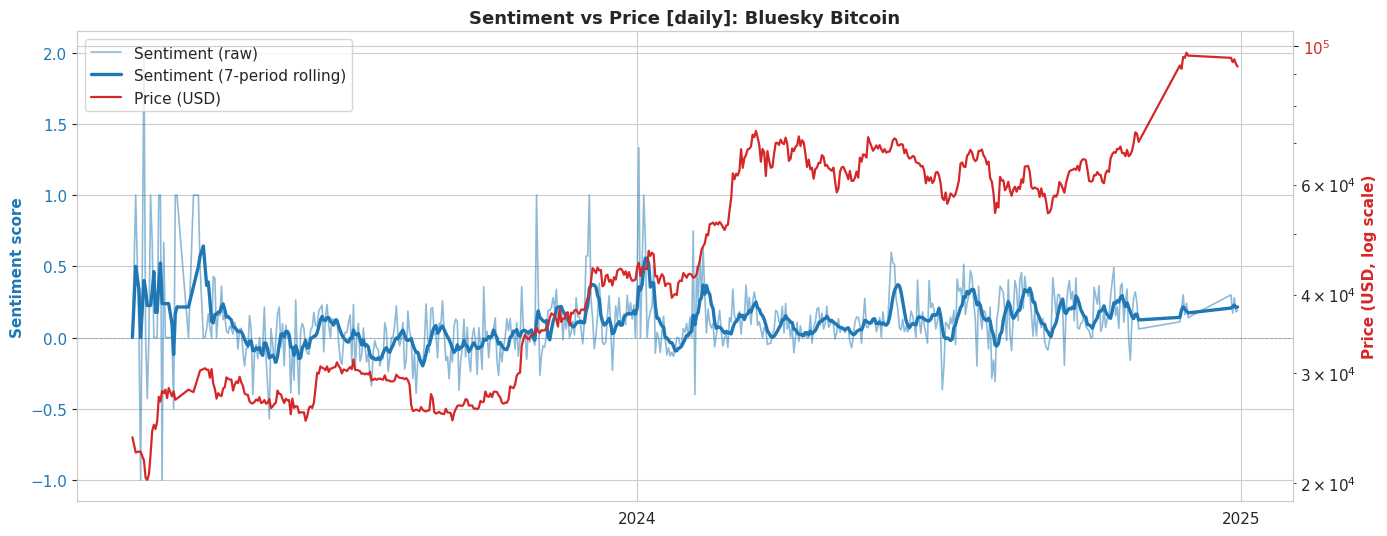

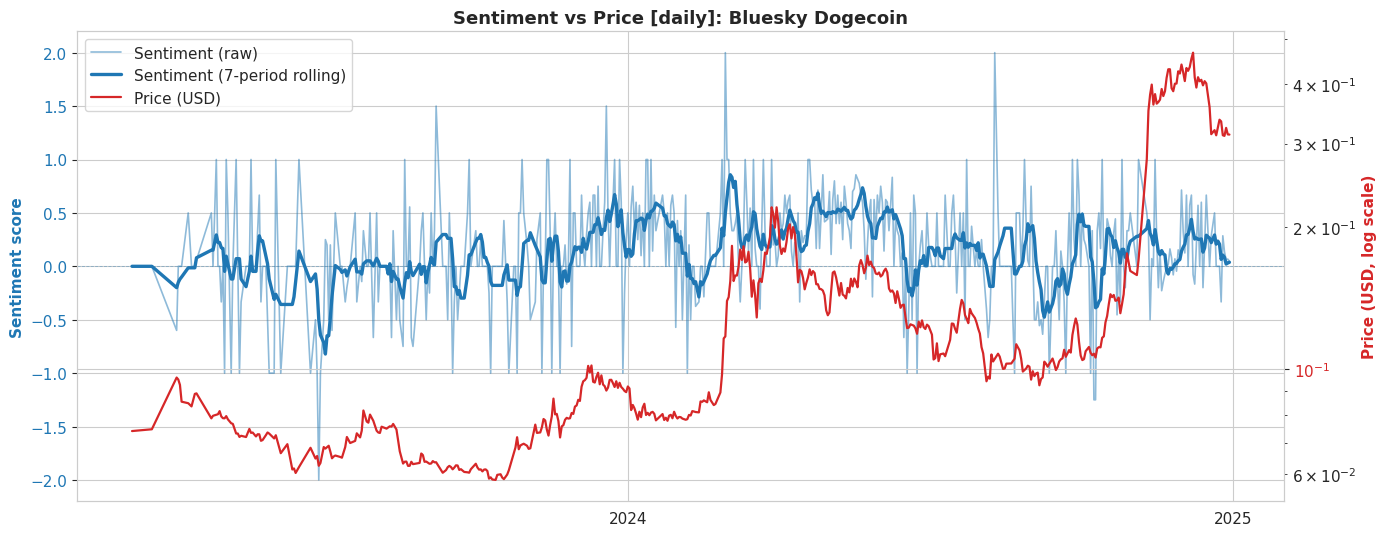

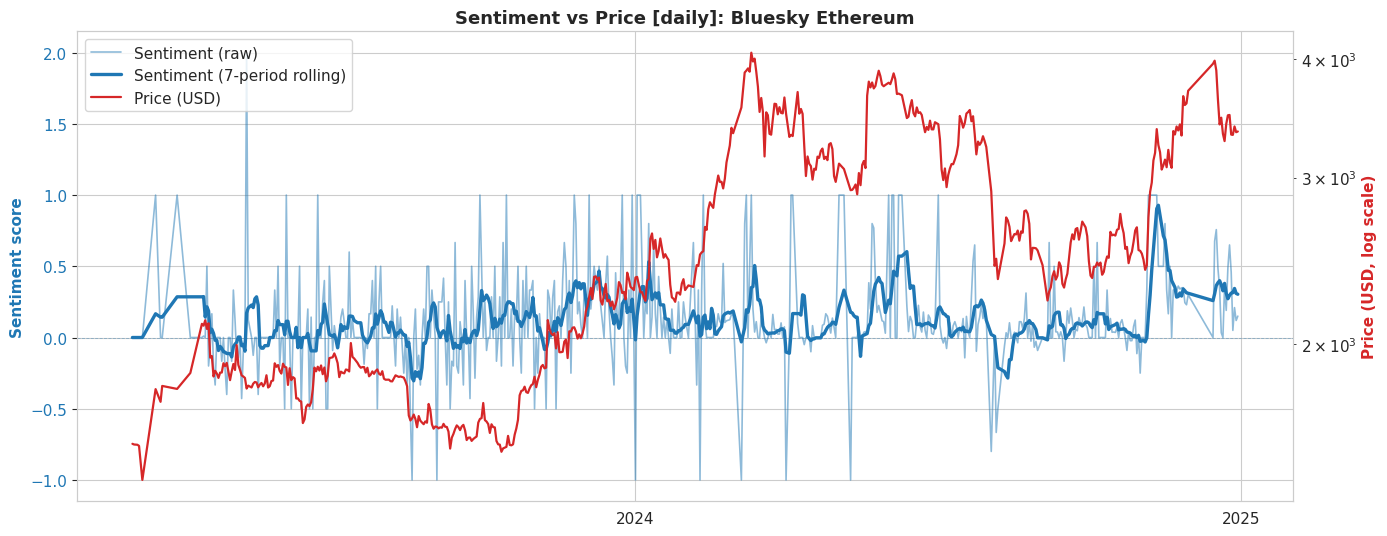

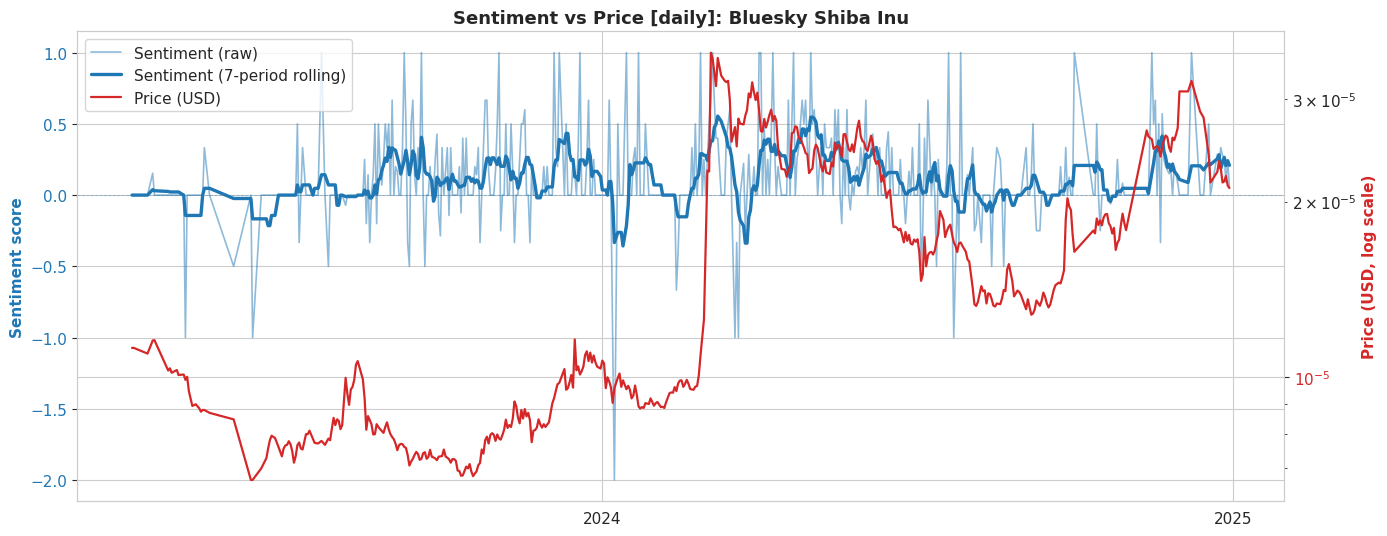

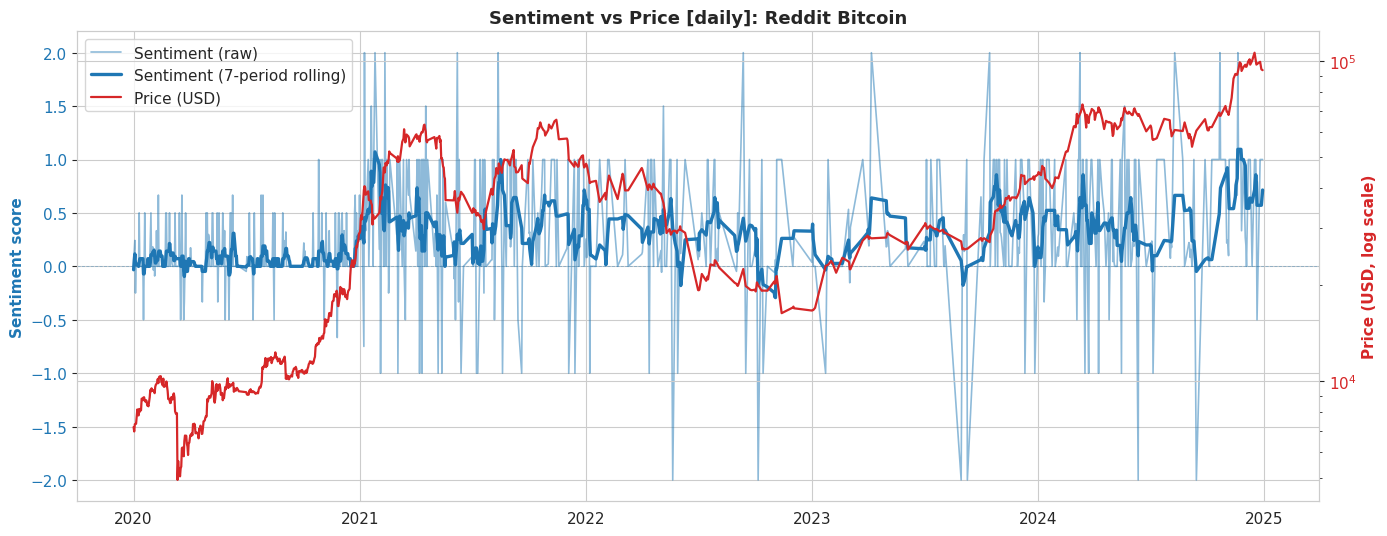

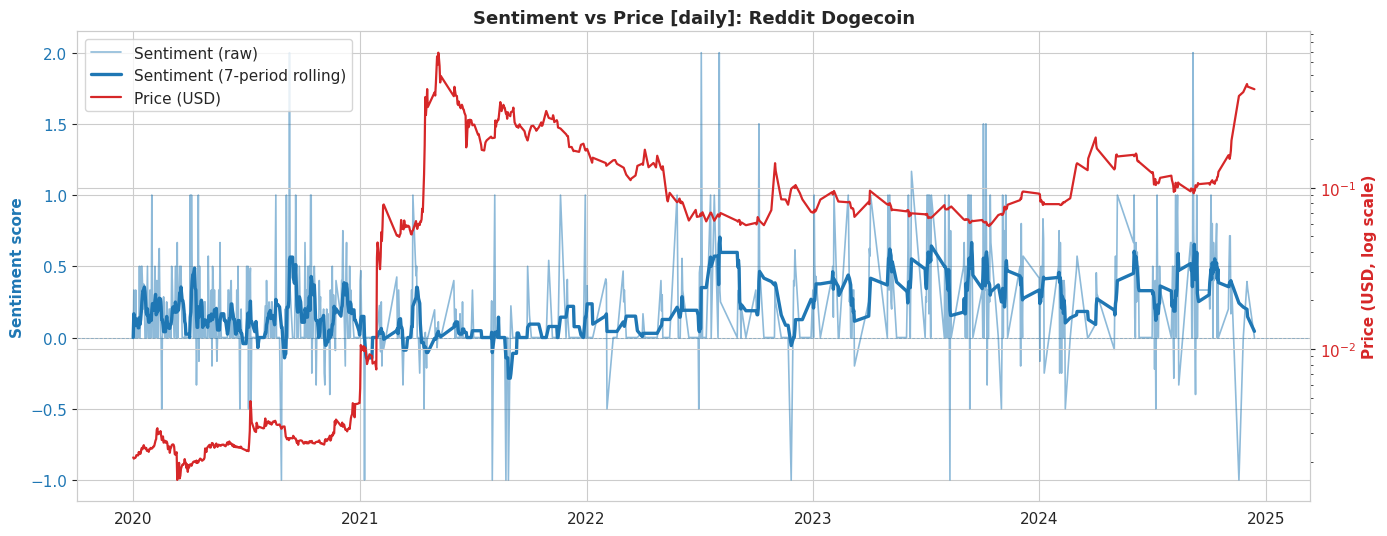

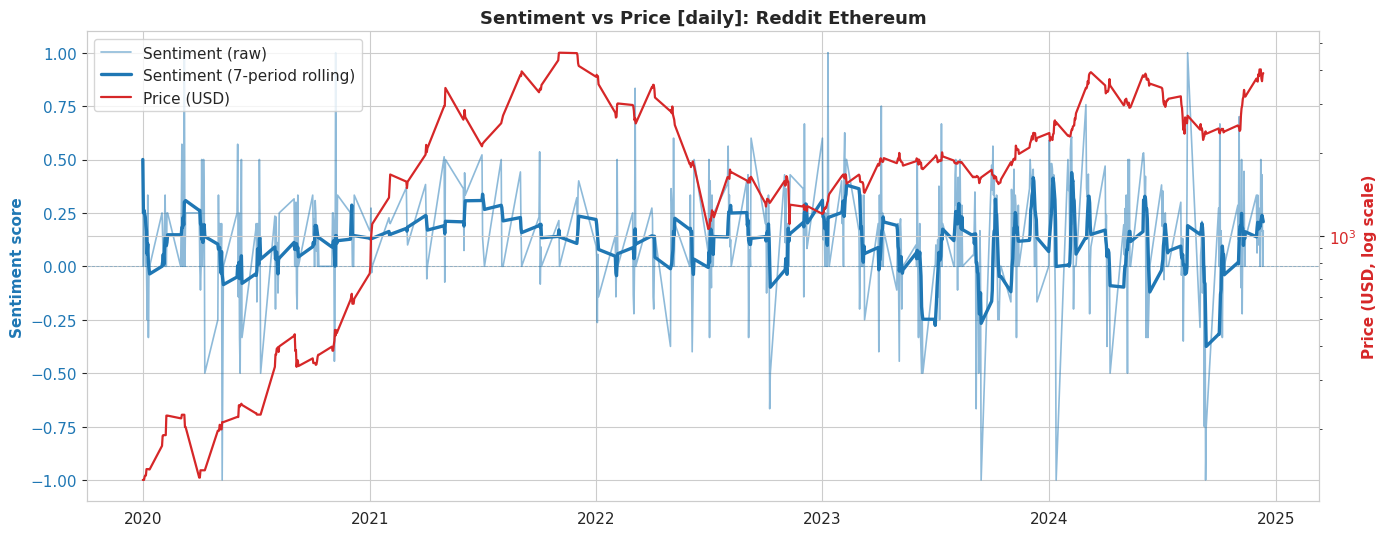

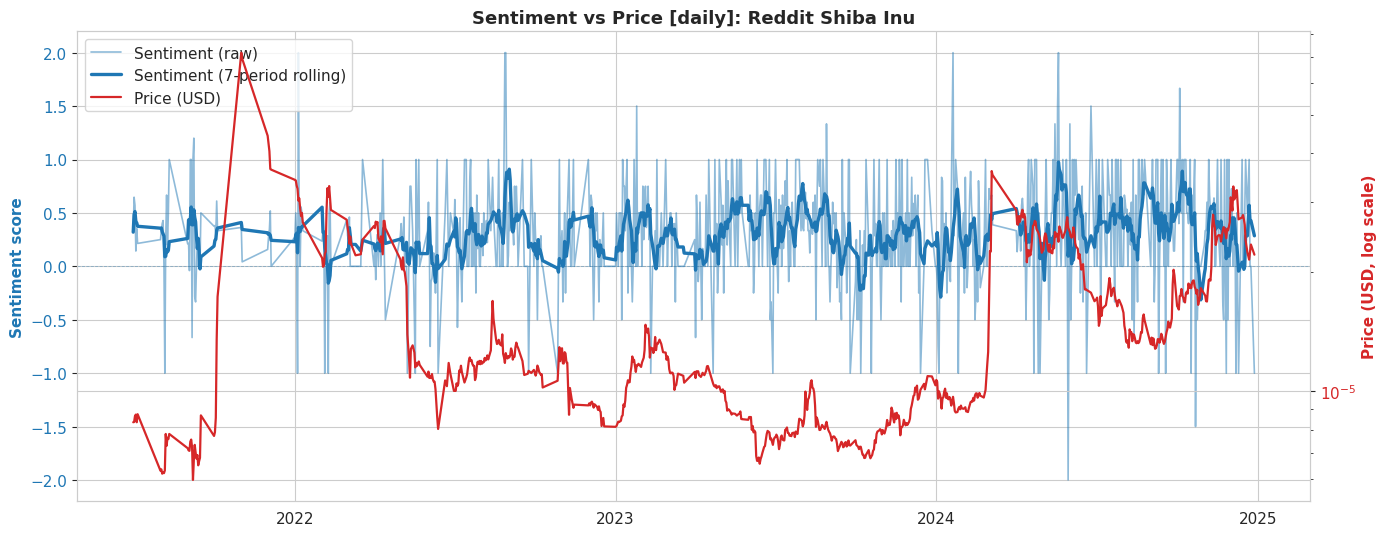

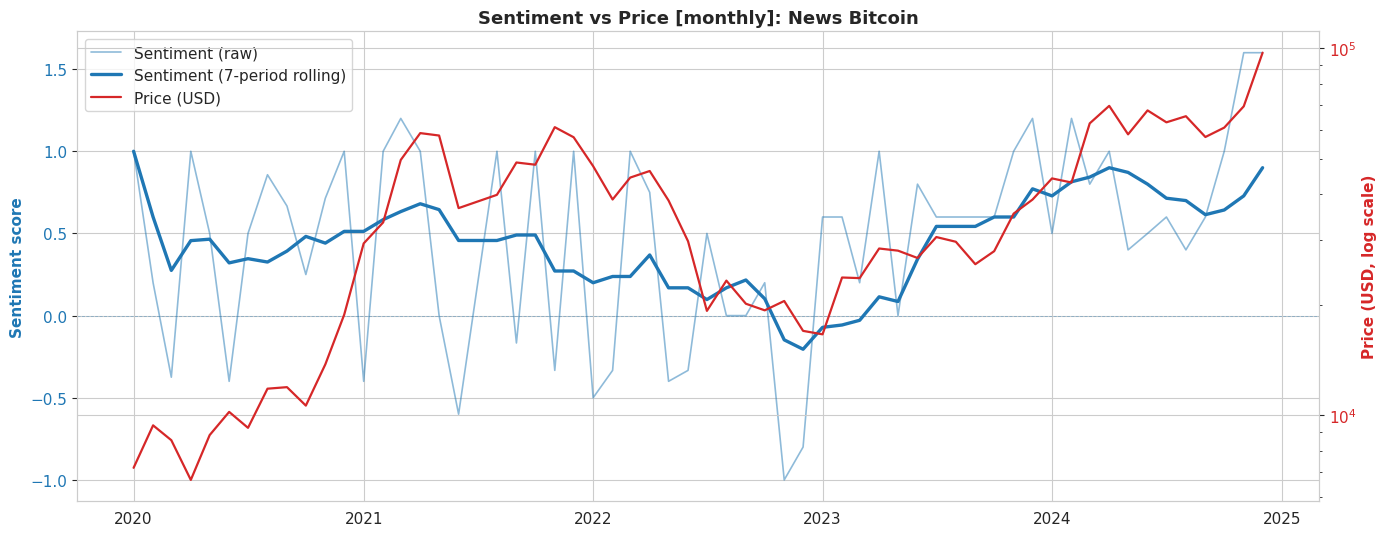

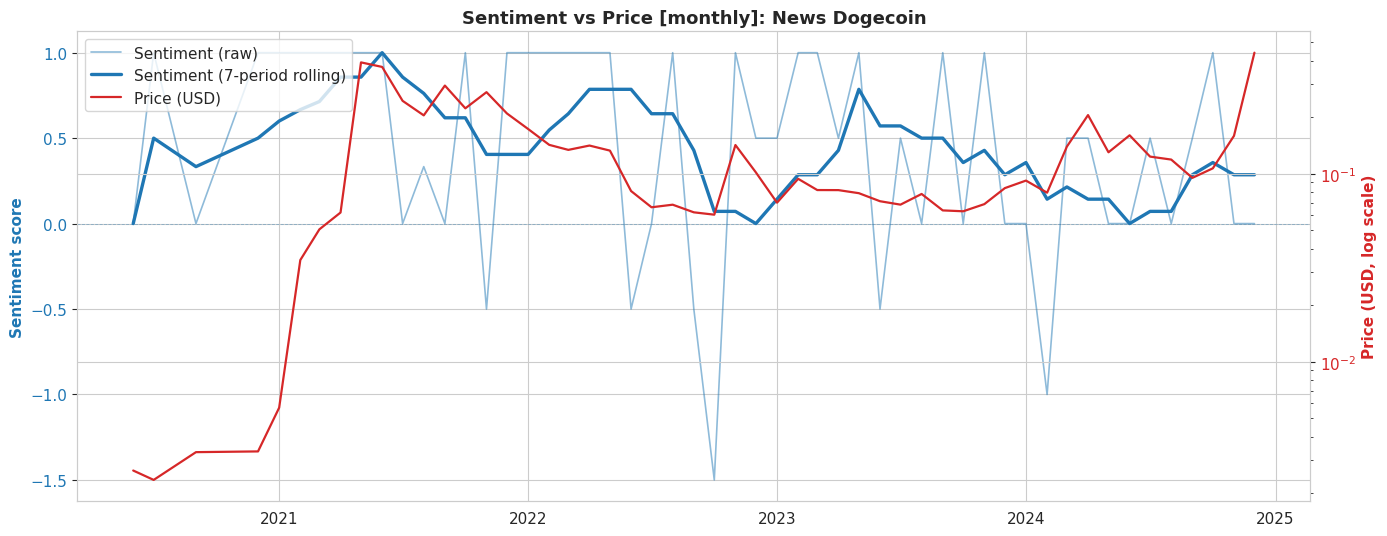

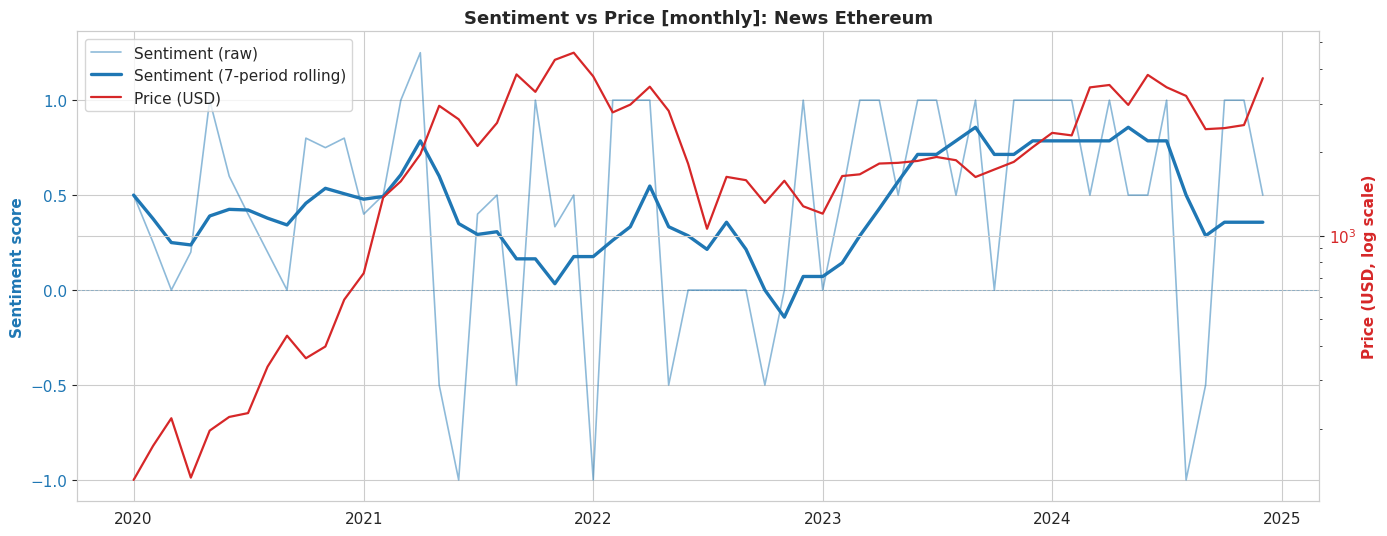

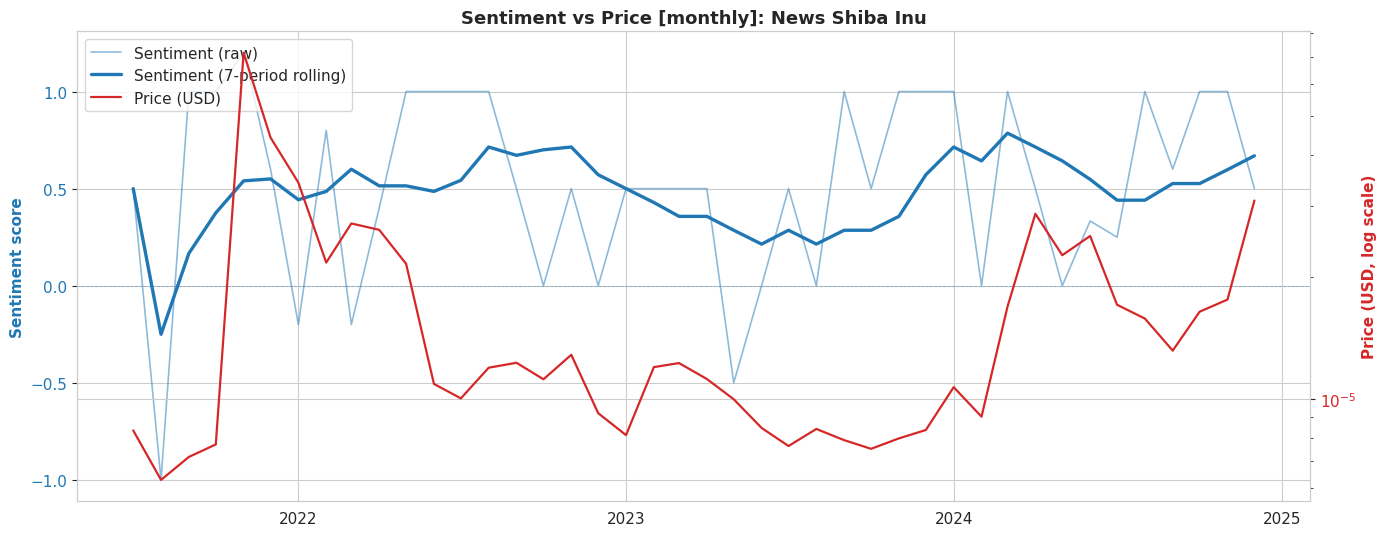

In [6]:
def plot_sentiment_vs_price(merged, title, save_path):
    fig, ax1 = plt.subplots(figsize=(14, 5.5))
    color_sent, color_price = '#1f77b4', '#d62728'
    ax1.plot(merged['date'], merged['sentiment_mean'], color=color_sent,
              linewidth=1.2, alpha=0.5, label='Sentiment (raw)')
    ax1.plot(merged['date'], merged['sentiment_mean'].rolling(7, min_periods=1).mean(),
              color=color_sent, linewidth=2.4, label='Sentiment (7-period rolling)')
    ax1.set_ylabel('Sentiment score', color=color_sent, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_sent)
    ax1.axhline(0, color=color_sent, linewidth=0.6, linestyle='--', alpha=0.4)

    ax2 = ax1.twinx()
    ax2.plot(merged['date'], merged['price_usd'], color=color_price,
              linewidth=1.6, label='Price (USD)')
    ax2.set_ylabel('Price (USD, log scale)', color=color_price, fontweight='bold')
    ax2.set_yscale('log')
    ax2.tick_params(axis='y', labelcolor=color_price)

    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.title(title)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

plotted = set()
for (name, freq), merged in panels.items():
    if name in plotted:
        continue
    plotted.add(name)
    plot_sentiment_vs_price(
        merged,
        title=f'Sentiment vs Price [{freq}]: {name.replace("_", " ").title()}',
        save_path=f'results/plots/01_timeseries_{name}.png'
    )

## 4. Stationarity Testing (Augmented Dickey-Fuller)

**What this test does:** The Augmented Dickey-Fuller (ADF) test checks whether a time series is *stationary* (statistical properties stay constant over time) or *non-stationary* (the series drifts or trends).

**Why it matters:** Granger causality, VAR, and transfer entropy all assume stationary inputs. Running them on non-stationary series produces spurious results.

**The hypothesis test:**
$$\text{H}_0: \text{the series has a unit root (non-stationary)}$$
$$\text{H}_1: \text{the series is stationary}$$

**Decision rule:** Reject $\text{H}_0$ if p-value < 0.05.

**Typical findings:** Raw prices are usually non-stationary (they trend). Log returns are usually stationary (they oscillate around zero). Sentiment may go either way.

In [7]:
def run_adf(series, name):
    series = series.dropna()
    if len(series) < 12 or series.std() == 0:
        return {'series': name, 'adf_stat': np.nan, 'p_value': np.nan,
                'stationary': None, 'note': 'insufficient data'}
    try:
        result = adfuller(series, autolag='AIC')
        return {'series': name,
                'adf_stat': round(result[0], 4),
                'p_value': round(result[1], 4),
                'stationary': result[1] < 0.05,
                'note': 'stationary' if result[1] < 0.05 else 'non-stationary'}
    except Exception as e:
        return {'series': name, 'adf_stat': np.nan, 'p_value': np.nan,
                'stationary': None, 'note': f'error: {e}'}

adf_rows = []
for (name, freq), merged in panels.items():
    for col in ['sentiment_mean', 'price_usd', 'log_return']:
        if col in merged.columns:
            adf_rows.append(run_adf(merged[col], f'{name} [{freq}] :: {col}'))

adf_df = pd.DataFrame(adf_rows)
adf_df.to_csv('results/tables/04_adf.csv', index=False)
print(adf_df.to_string(index=False))

                                       series  adf_stat  p_value  stationary           note
    bluesky_bitcoin [daily] :: sentiment_mean   -3.8021   0.0029        True     stationary
         bluesky_bitcoin [daily] :: price_usd    0.0063   0.9590       False non-stationary
        bluesky_bitcoin [daily] :: log_return  -16.5417   0.0000        True     stationary
   bluesky_bitcoin [weekly] :: sentiment_mean   -3.9963   0.0014        True     stationary
        bluesky_bitcoin [weekly] :: price_usd   -0.0469   0.9545       False non-stationary
       bluesky_bitcoin [weekly] :: log_return   -9.1051   0.0000        True     stationary
  bluesky_bitcoin [monthly] :: sentiment_mean   -1.5190   0.5241       False non-stationary
       bluesky_bitcoin [monthly] :: price_usd    1.1585   0.9957       False non-stationary
      bluesky_bitcoin [monthly] :: log_return   -1.7007   0.4307       False non-stationary
   bluesky_dogecoin [daily] :: sentiment_mean   -7.4894   0.0000        True    

## 4b. Optimal Lag Selection (Information Criteria)

**Why this matters methodologically:** A common criticism of multi-lag testing is that it amounts to multiple hypothesis testing without correction. If you test lags 1 through 7 and report the smallest p-value, the chance of at least one lag appearing significant by random chance is much higher than 5%, even if no real effect exists.

**The principled alternative:** Use information criteria to *pre-select* the optimal lag for each panel before running causality tests. Then report results at that single chosen lag as the headline finding. The multi-lag scan results are kept as appendix robustness checks.

**The two information criteria used:**
$$\text{AIC} = 2k - 2\ln(L) \qquad \text{BIC} = k\ln(n) - 2\ln(L)$$

Where $k$ is the number of parameters, $L$ is the maximum likelihood, and $n$ is the sample size. Both criteria reward better model fit and penalise complexity. **AIC tends to choose slightly larger models; BIC chooses more parsimonious models.** When they disagree, we use AIC for the main analysis (since slightly over-parameterised is safer than under-parameterised for causality testing).

**Implementation:** For each panel, fit a Vector Autoregression (VAR) on (sentiment, log return) and choose the lag order that minimises AIC, capped at the frequency-appropriate maximum.

**Caps by frequency:**
- Daily: maximum 7 lags (one trading week of memory).
- Weekly: maximum 4 lags (one month of memory).
- Monthly: maximum 6 lags (half a year of memory).

In [8]:
MAX_LAG_BY_FREQ = {'daily': 7, 'weekly': 4, 'monthly': 6}

def select_optimal_lag(merged, max_lag):
    """
    Fit VAR(p) for p = 1..max_lag and return the optimal lag by AIC.
    Falls back to lag 1 if optimisation fails.
    """
    if 'log_return' not in merged.columns:
        return 1, np.nan, np.nan
    data = merged[['sentiment_mean', 'log_return']].dropna()
    if len(data) < (max_lag * 5 + 5):
        return 1, np.nan, np.nan
    try:
        model = VAR(data)
        max_p = min(max_lag, len(data) // 8)
        if max_p < 1:
            return 1, np.nan, np.nan
        sel = model.select_order(maxlags=max_p)
        opt = max(1, sel.aic)
        bic = max(1, sel.bic)
        return opt, opt, bic
    except Exception:
        return 1, np.nan, np.nan

optimal_lags = {}
lag_rows = []
for (name, freq), merged in panels.items():
    cap = MAX_LAG_BY_FREQ[freq]
    opt_aic, _, opt_bic = select_optimal_lag(merged, cap)
    optimal_lags[(name, freq)] = opt_aic
    lag_rows.append({
        'panel': name, 'frequency': freq,
        'n_obs': len(merged),
        'max_lag_cap': cap,
        'optimal_lag_aic': opt_aic,
        'optimal_lag_bic': int(opt_bic) if not np.isnan(opt_bic) else None,
    })

optimal_lag_df = pd.DataFrame(lag_rows).sort_values(['panel', 'frequency'])
optimal_lag_df.to_csv('results/tables/04b_optimal_lags.csv', index=False)
print('OPTIMAL LAG SELECTION (chosen by AIC):')
print('=' * 70)
print(optimal_lag_df.to_string(index=False))

OPTIMAL LAG SELECTION (chosen by AIC):
            panel frequency  n_obs  max_lag_cap  optimal_lag_aic  optimal_lag_bic
  bluesky_bitcoin     daily    607            7                4              1.0
  bluesky_bitcoin   monthly     22            6                1              NaN
  bluesky_bitcoin    weekly     91            4                2              1.0
 bluesky_dogecoin     daily    534            7                3              1.0
 bluesky_dogecoin   monthly     22            6                1              NaN
 bluesky_dogecoin    weekly     93            4                3              1.0
 bluesky_ethereum     daily    583            7                3              1.0
 bluesky_ethereum   monthly     22            6                1              NaN
 bluesky_ethereum    weekly     96            4                2              1.0
bluesky_shiba_inu     daily    511            7                2              1.0
bluesky_shiba_inu   monthly     21            6            

## 5. Contemporaneous Correlation

**What this measures:** How strongly sentiment and market variables move together within the same period. Computed at every frequency to see whether the relationship strengthens or weakens with aggregation.

**The two correlation measures used:**
- **Pearson correlation:** parametric, sensitive to outliers, measures *linear* relationship.
- **Spearman correlation:** rank-based, robust to outliers, measures any *monotonic* relationship.

**Pearson formula:**
$$r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2 \sum_i (y_i - \bar{y})^2}}$$

**How to interpret:**
- Coefficient between $-1$ and $+1$. Larger absolute value means stronger relationship.
- Sign indicates direction: positive means series move together; negative means opposite.
- p-value tests $\text{H}_0: r = 0$. Look for p < 0.05.
- Significance stars: `***` p<0.01, `**` p<0.05, `*` p<0.1.

**Important caveat:** Correlation says nothing about *causation* or *direction*. It just says they move together.

In [9]:
def correlation_tests(merged, sent_col='sentiment_mean'):
    rows = []
    for mkt in ['log_return', 'price_usd', 'volatility_7d', 'volume_usd']:
        if mkt not in merged.columns:
            continue
        valid = merged[[sent_col, mkt]].dropna()
        if len(valid) < 12:
            continue
        p_r, p_p = stats.pearsonr(valid[sent_col], valid[mkt])
        s_r, s_p = stats.spearmanr(valid[sent_col], valid[mkt])
        sig = lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        rows.append({
            'market_var': mkt, 'n': len(valid),
            'pearson_r': round(p_r, 4), 'pearson_p': round(p_p, 4), 'p_sig': sig(p_p),
            'spearman_r': round(s_r, 4), 'spearman_p': round(s_p, 4), 's_sig': sig(s_p),
        })
    return pd.DataFrame(rows)

corr_all = []
for (name, freq), merged in panels.items():
    cdf = correlation_tests(merged)
    if cdf.empty:
        continue
    cdf.insert(0, 'frequency', freq)
    cdf.insert(0, 'panel', name)
    corr_all.append(cdf)

correlation_df = pd.concat(corr_all, ignore_index=True) if corr_all else pd.DataFrame()
correlation_df.to_csv('results/tables/05_correlation.csv', index=False)

for name in sorted(set(correlation_df['panel'])):
    sub = correlation_df[correlation_df['panel'] == name]
    print(f'\n--- {name} ---')
    print(sub.drop('panel', axis=1).to_string(index=False))


--- bluesky_bitcoin ---
frequency    market_var   n  pearson_r  pearson_p p_sig  spearman_r  spearman_p s_sig
    daily    log_return 607     0.1708     0.0000   ***      0.1759      0.0000   ***
    daily     price_usd 607     0.2070     0.0000   ***      0.3834      0.0000   ***
    daily volatility_7d 607     0.0943     0.0202    **      0.1483      0.0002   ***
    daily    volume_usd 607     0.1679     0.0000   ***      0.2928      0.0000   ***
   weekly    log_return  91     0.2701     0.0096   ***      0.3087      0.0029   ***
   weekly     price_usd  91     0.2861     0.0060   ***      0.5172      0.0000   ***
   weekly volatility_7d  91     0.2299     0.0283    **      0.2996      0.0039   ***
   weekly    volume_usd  91     0.2261     0.0312    **      0.4611      0.0000   ***
  monthly    log_return  22     0.0849     0.7072            0.0333      0.8830      
  monthly     price_usd  22     0.7027     0.0003   ***      0.6533      0.0010   ***
  monthly volatility_7d  22  

## 6. Lead-Lag Cross-Correlation

**What this measures:** Correlation between sentiment and returns at different time lags. Reveals whether sentiment *leads* returns (predictive) or returns *lead* sentiment (reactive).

**Mathematical definition:**
$$\rho_{xy}(k) = \frac{\text{Cov}(x_t, y_{t+k})}{\sigma_x \sigma_y}$$

Where $k$ is the lag in periods. The maximum lag examined is set to twice the optimal VAR lag determined in Section 4b, so the plot extends well beyond what the formal causality tests cover but stays anchored to the data-driven specification.

**How to read the plot:**
- **Negative lag** (left side): correlation when *returns occurred earlier* than sentiment. Bars here mean prices led sentiment.
- **Lag 0** (centre): contemporaneous correlation.
- **Positive lag** (right side): correlation when *sentiment occurred earlier* than returns. Bars here mean sentiment led prices.
- The dashed lines show the 95% significance bound at $\pm 1.96/\sqrt{n}$.

**Pattern interpretation:**
- Big bars on positive lags only: sentiment is a leading indicator.
- Big bars on negative lags only: sentiment is a lagging indicator.
- Big bars on both sides: feedback loop between sentiment and prices.
- All bars within significance bounds: no useful lead-lag relationship.

Plots are produced for the daily frequency only (where most data is available).

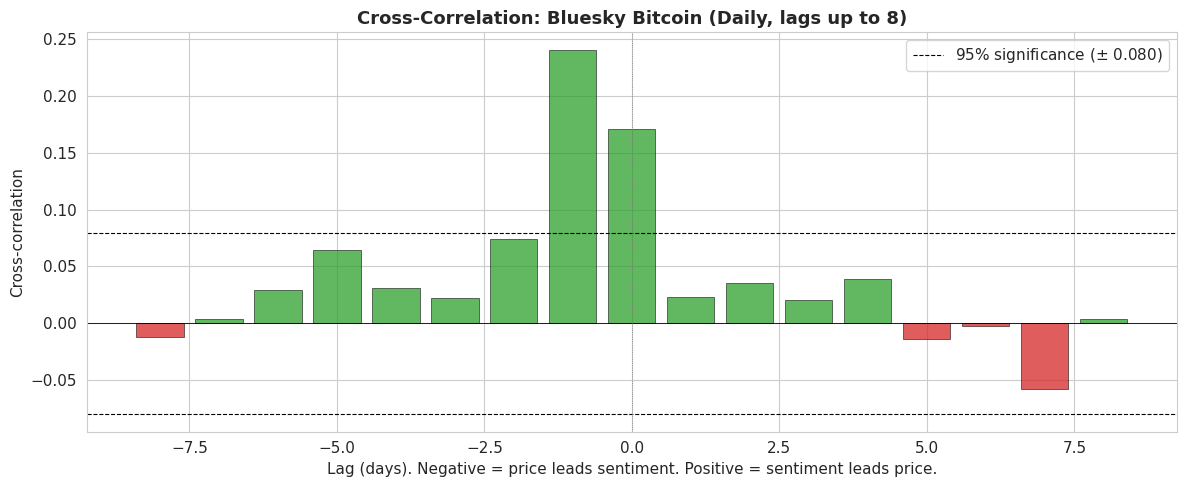

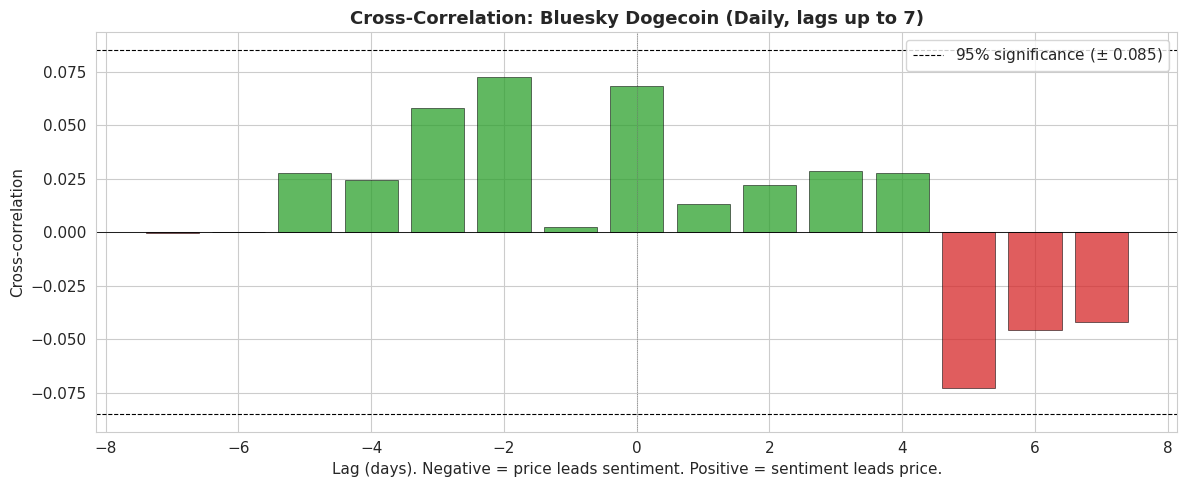

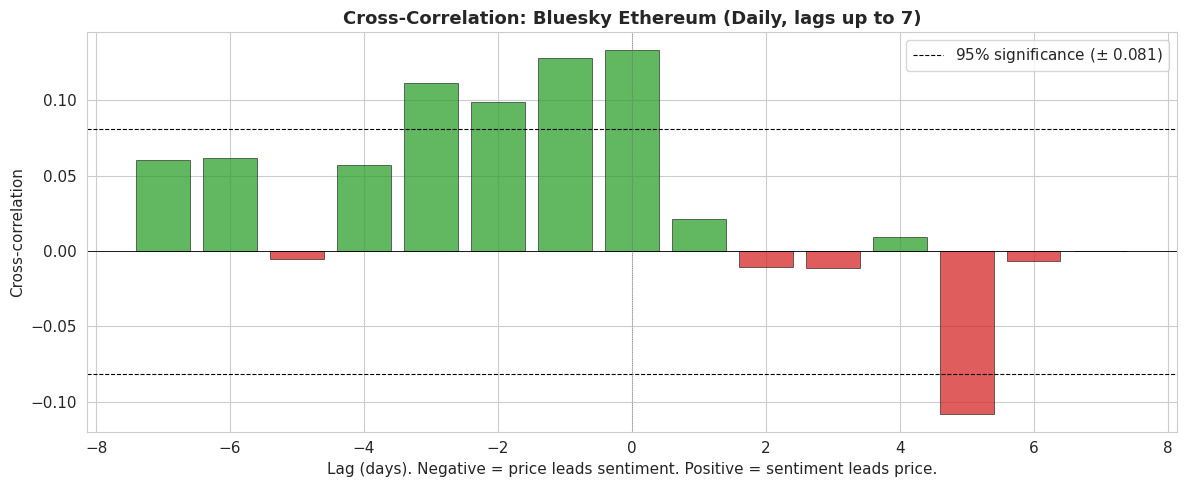

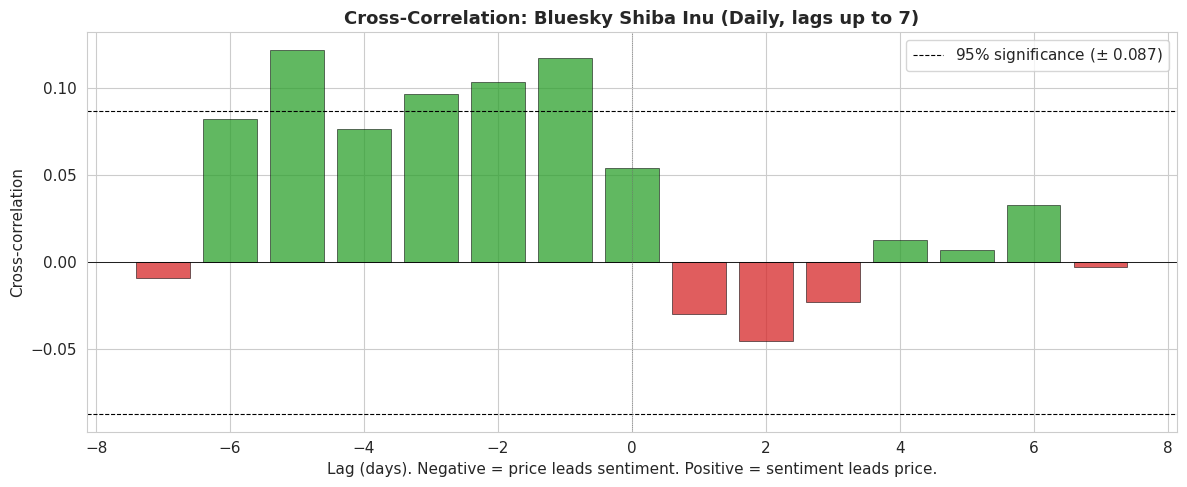

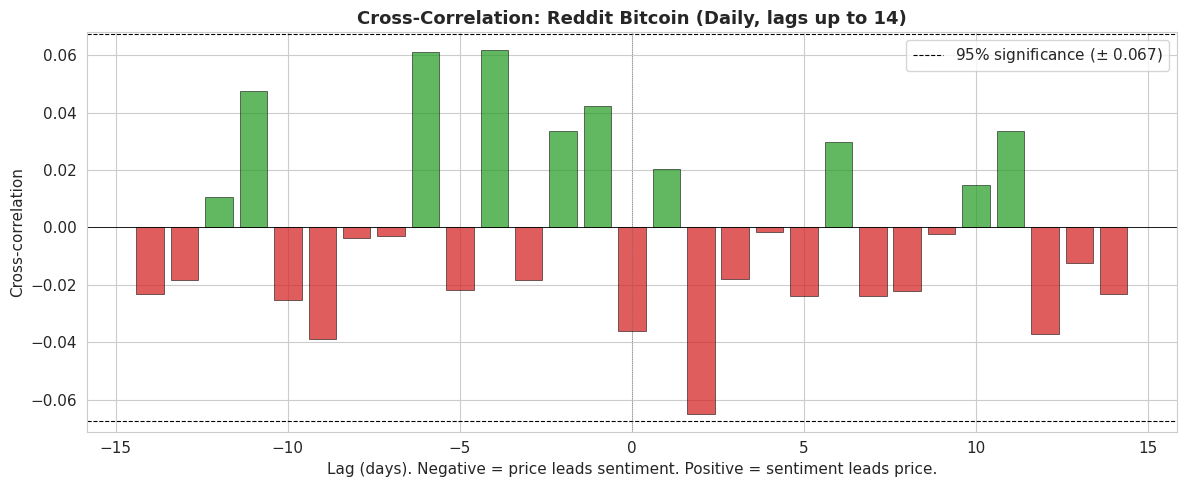

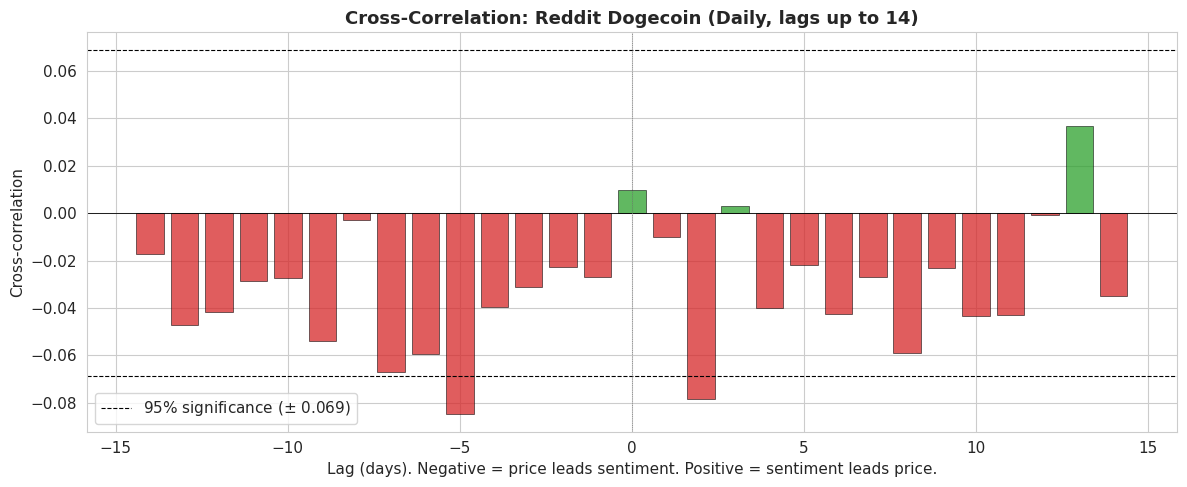

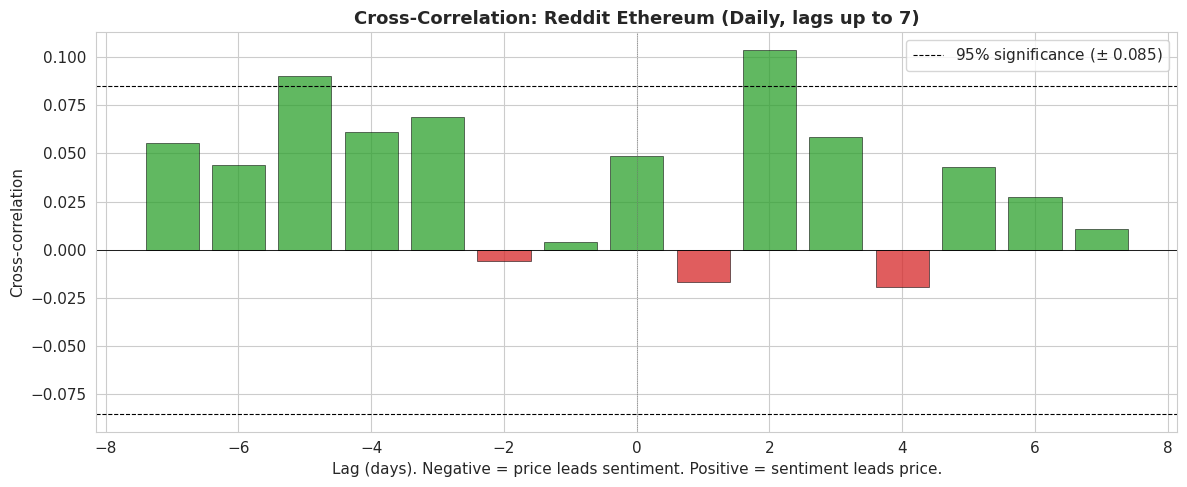

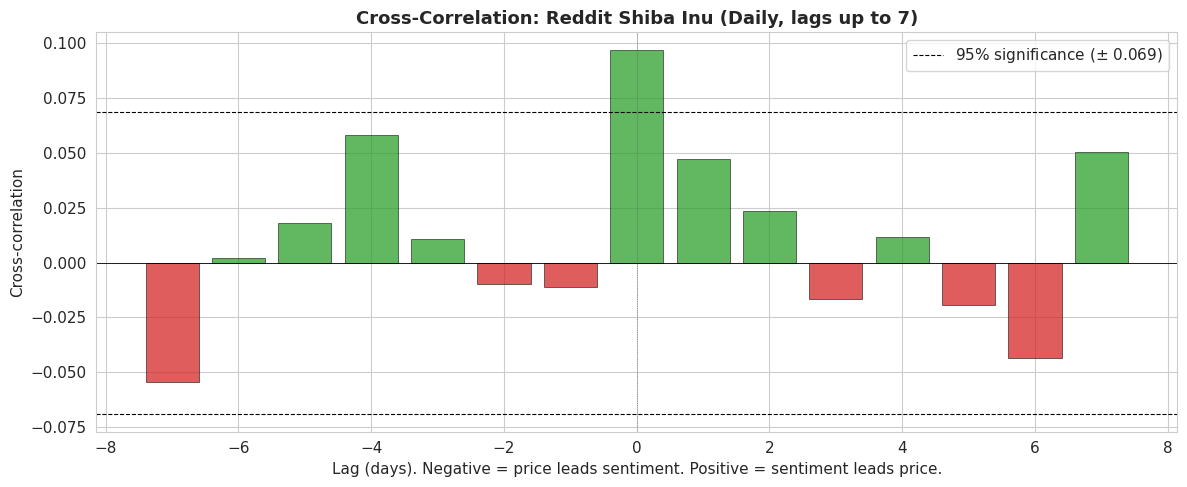

In [10]:
def plot_cross_correlation(merged, title, save_path, max_lag):
    if 'log_return' not in merged.columns:
        return None
    aligned = merged[['sentiment_mean', 'log_return']].dropna()
    if len(aligned) < 60:
        return None
    sent_v, ret_v = aligned['sentiment_mean'].values, aligned['log_return'].values
    lags = list(range(-max_lag, max_lag + 1))
    corrs = []
    for k in lags:
        if k < 0:
            a, b = ret_v[:k], sent_v[-k:]
        elif k > 0:
            a, b = sent_v[:-k], ret_v[k:]
        else:
            a, b = sent_v, ret_v
        corrs.append(np.corrcoef(a, b)[0, 1] if len(a) >= 20 else np.nan)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(lags, corrs, color=['#d62728' if c < 0 else '#2ca02c' for c in corrs],
           alpha=0.75, edgecolor='black', linewidth=0.5)
    sig = 1.96 / np.sqrt(len(aligned))
    ax.axhline(sig, color='black', linestyle='--', linewidth=0.8,
               label=f'95% significance ($\\pm$ {sig:.3f})')
    ax.axhline(-sig, color='black', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.axvline(0, color='grey', linewidth=0.6, linestyle=':')
    ax.set_xlabel('Lag (days). Negative = price leads sentiment. Positive = sentiment leads price.')
    ax.set_ylabel('Cross-correlation')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    return pd.DataFrame({'lag': lags, 'correlation': corrs})

ccf_results = {}
for (name, freq), merged in panels.items():
    if freq != 'daily':
        continue
    opt_lag = optimal_lags.get((name, freq), 1)
    max_lag_plot = max(7, opt_lag * 2)
    df = plot_cross_correlation(
        merged,
        title=f'Cross-Correlation: {name.replace("_", " ").title()} (Daily, lags up to {max_lag_plot})',
        save_path=f'results/plots/06_ccf_{name}.png',
        max_lag=max_lag_plot,
    )
    if df is not None:
        ccf_results[name] = df

## 7. Granger Causality at Optimal Lag (Headline Test) + Multi-Lag Robustness

**What Granger causality tests:** Whether past values of one time series help predict future values of another, beyond what the second series's own past predicts.

**Mathematical formulation:** For two series $X$ and $Y$, fit two regressions:
$$\text{Restricted: } y_t = \alpha_0 + \sum_{i=1}^{p} \alpha_i y_{t-i} + \varepsilon_t^R$$
$$\text{Unrestricted: } y_t = \alpha_0 + \sum_{i=1}^{p} \alpha_i y_{t-i} + \sum_{i=1}^{p} \beta_i x_{t-i} + \varepsilon_t^U$$

Then test $\text{H}_0: \beta_1 = \beta_2 = ... = \beta_p = 0$ via an F-test on the residual sum of squares.

**Two directions tested:**
1. **Sentiment $\rightarrow$ Returns:** Does past sentiment predict future returns? (The dissertation's key hypothesis.)
2. **Returns $\rightarrow$ Sentiment:** Do past returns predict future sentiment? (Reverse-direction sanity check.)

**Interpretation cheat sheet:**
- **Sentiment$\rightarrow$Returns significant, Returns$\rightarrow$Sentiment not significant:** Strong evidence that sentiment predicts returns. **Headline finding.**
- **Returns$\rightarrow$Sentiment significant, Sentiment$\rightarrow$Returns not significant:** Sentiment is a lagging indicator (reactive, not predictive).
- **Both significant:** Genuine feedback loop.
- **Neither significant:** No predictive relationship.

**Three reporting layers:**
1. **Headline result (Table A):** Granger test at the AIC-selected optimal lag from Section 4b. This is the methodologically principled result.
2. **Best-lag result (Table B):** For each panel and direction, the lag that produces the smallest p-value across the full scan. Where this differs from the AIC lag, it reveals relationships that exist at a different time horizon than the one AIC selected. The table flags cases where the best lag is significant but the AIC lag is not, labelled as "hidden by AIC".
3. **Full lag scan (Table C):** Granger test at every lag from 1 to the frequency-appropriate cap. This goes in the appendix and lets you see the full lag profile for each panel.

In [11]:
def run_granger_at_lag(merged, lag, x_col='sentiment_mean', y_col='log_return'):
    """Run Granger causality at a single specific lag in both directions."""
    data = merged[[x_col, y_col]].dropna()
    if len(data) < (lag * 5 + 5):
        return []
    rows = []
    for direction, cols in [
        ('sentiment -> returns', [y_col, x_col]),
        ('returns -> sentiment', [x_col, y_col]),
    ]:
        try:
            result = grangercausalitytests(data[cols], maxlag=[lag], verbose=False)
            f_stat = result[lag][0]['ssr_ftest'][0]
            p_val = result[lag][0]['ssr_ftest'][1]
            rows.append({
                'direction': direction, 'lag': lag,
                'f_stat': round(f_stat, 3), 'p_value': round(p_val, 4),
                'significant_5pct': p_val < 0.05, 'n_obs': len(data),
            })
        except Exception:
            continue
    return rows

def run_granger_scan(merged, max_lag, x_col='sentiment_mean', y_col='log_return'):
    """Run Granger causality at every lag from 1 to max_lag in both directions."""
    data = merged[[x_col, y_col]].dropna()
    if len(data) < (max_lag * 5):
        return []
    rows = []
    for direction, cols in [
        ('sentiment -> returns', [y_col, x_col]),
        ('returns -> sentiment', [x_col, y_col]),
    ]:
        try:
            result = grangercausalitytests(data[cols], maxlag=max_lag, verbose=False)
            for lag in range(1, max_lag + 1):
                f_stat = result[lag][0]['ssr_ftest'][0]
                p_val = result[lag][0]['ssr_ftest'][1]
                rows.append({
                    'direction': direction, 'lag': lag,
                    'f_stat': round(f_stat, 3), 'p_value': round(p_val, 4),
                    'significant_5pct': p_val < 0.05, 'n_obs': len(data),
                })
        except Exception:
            continue
    return rows

# Headline results: at the optimal lag.
granger_headline = []
for (name, freq), merged in panels.items():
    if 'log_return' not in merged.columns:
        continue
    opt = optimal_lags[(name, freq)]
    for r in run_granger_at_lag(merged, opt):
        r['panel'], r['frequency'] = name, freq
        granger_headline.append(r)

# Full lag scan: every lag from 1 to frequency cap.
granger_scan = []
for (name, freq), merged in panels.items():
    if 'log_return' not in merged.columns:
        continue
    for r in run_granger_scan(merged, MAX_LAG_BY_FREQ[freq]):
        r['panel'], r['frequency'] = name, freq
        granger_scan.append(r)

granger_headline_df = pd.DataFrame(granger_headline)
granger_scan_df = pd.DataFrame(granger_scan)

# Reorder columns.
front = ['panel', 'frequency']
cols_order = front + ['direction', 'lag', 'f_stat', 'p_value', 'significant_5pct', 'n_obs']
if not granger_headline_df.empty:
    granger_headline_df = granger_headline_df[cols_order]
if not granger_scan_df.empty:
    granger_scan_df = granger_scan_df[cols_order]

granger_headline_df.to_csv('results/tables/07a_granger_headline.csv', index=False)
granger_scan_df.to_csv('results/tables/07b_granger_scan.csv', index=False)

# --- Extract best lag per (panel, frequency, direction) from the full scan ---
# This finds the lag with the smallest p-value for each direction,
# giving us a "best available" result that may differ from the AIC-selected lag.
granger_best_lag = []
if not granger_scan_df.empty:
    for (panel, freq, direction), group in granger_scan_df.groupby(['panel', 'frequency', 'direction']):
        best = group.loc[group['p_value'].idxmin()]
        granger_best_lag.append({
            'panel': panel, 'frequency': freq, 'direction': direction,
            'best_lag': int(best['lag']),
            'best_f_stat': best['f_stat'],
            'best_p_value': best['p_value'],
            'best_significant': best['significant_5pct'],
            'optimal_lag': optimal_lags.get((panel, freq), None),
            'optimal_lag_p': None,  # filled below
            'n_obs': int(best['n_obs']),
        })

granger_best_df = pd.DataFrame(granger_best_lag)

# Fill in the optimal-lag p-value for comparison.
if not granger_best_df.empty and not granger_headline_df.empty:
    for idx, row in granger_best_df.iterrows():
        match = granger_headline_df[
            (granger_headline_df['panel'] == row['panel']) &
            (granger_headline_df['frequency'] == row['frequency']) &
            (granger_headline_df['direction'] == row['direction'])
        ]
        if not match.empty:
            granger_best_df.at[idx, 'optimal_lag_p'] = float(match['p_value'].iloc[0])

granger_best_df.to_csv('results/tables/07c_granger_best_lag.csv', index=False)

print('=' * 80)
print('A. HEADLINE GRANGER RESULTS (at AIC-selected optimal lag)')
print('=' * 80)
print(granger_headline_df.to_string(index=False))

print('\n\n' + '=' * 80)
print('B. BEST-LAG GRANGER RESULTS (lag with smallest p-value across full scan)')
print('    Comparison: optimal_lag_p = p-value at AIC lag; best_p_value = p-value at best lag')
print('    Where these differ, the full scan reveals structure the optimal lag missed.')
print('=' * 80)
if not granger_best_df.empty:
    # Flag cases where the best lag finds significance but the optimal lag does not.
    granger_best_df['hidden_by_aic'] = (
        (granger_best_df['best_significant'] == True) &
        (granger_best_df['optimal_lag_p'].notna()) &
        (granger_best_df['optimal_lag_p'] >= 0.05)
    )
    print(granger_best_df.to_string(index=False))

    hidden = granger_best_df[granger_best_df['hidden_by_aic']]
    if not hidden.empty:
        print(f'\n*** {len(hidden)} significant relationships HIDDEN by AIC lag selection: ***')
        print(hidden[['panel', 'frequency', 'direction', 'best_lag', 'best_p_value',
                        'optimal_lag', 'optimal_lag_p']].to_string(index=False))

print('\n\n' + '=' * 80)
print('C. FULL LAG SCAN (all lags, for appendix)')
print('=' * 80)
for name in sorted(set(granger_scan_df['panel'])):
    print(f'\n=== {name} ===')
    for freq in ['daily', 'weekly', 'monthly']:
        sub = granger_scan_df[(granger_scan_df['panel'] == name) & (granger_scan_df['frequency'] == freq)]
        if sub.empty:
            continue
        print(f'\n  [{freq.upper()}]')
        print(sub.drop(['panel', 'frequency'], axis=1).to_string(index=False))

A. HEADLINE GRANGER RESULTS (at AIC-selected optimal lag)
            panel frequency            direction  lag  f_stat  p_value  significant_5pct  n_obs
  bluesky_bitcoin     daily sentiment -> returns    4   0.377   0.8250             False    607
  bluesky_bitcoin     daily returns -> sentiment    4   8.387   0.0000              True    607
  bluesky_bitcoin    weekly sentiment -> returns    2   0.389   0.6792             False     91
  bluesky_bitcoin    weekly returns -> sentiment    2   0.472   0.6255             False     91
  bluesky_bitcoin   monthly sentiment -> returns    1   1.842   0.1915             False     22
  bluesky_bitcoin   monthly returns -> sentiment    1   0.000   0.9922             False     22
 bluesky_dogecoin     daily sentiment -> returns    3   0.172   0.9155             False    534
 bluesky_dogecoin     daily returns -> sentiment    3   1.015   0.3857             False    534
 bluesky_dogecoin    weekly sentiment -> returns    3   0.389   0.7615        

## 8. Returns-on-Returns Analysis (Momentum vs Mean-Reversion Baseline)

**What this test does:** Tests whether past returns predict future returns of the same asset, **independent of any sentiment effect**. This establishes a baseline that any sentiment-predicts-returns finding must beat to be meaningful.

**Three patterns this test can reveal:**
- **Momentum:** Past positive returns predict future positive returns. Coefficient $> 0$.
- **Mean-reversion:** Past positive returns predict future negative returns. Coefficient $< 0$.
- **Random walk:** No relationship. Past returns contain no information about future returns. This is the efficient-market baseline.

**Why this matters for the dissertation:** If returns auto-predict through momentum, then a sentiment-predicts-returns finding needs to add value *beyond* that momentum. Conversely, if returns do not auto-predict, any significant sentiment finding is more remarkable because sentiment carries genuinely external information.

**The model used:** AR(p) regression of return at time $t$ on return at time $t-p$:
$$r_t = \alpha + \beta r_{t-p} + \varepsilon_t$$

**The test:** Wald t-test on $\beta$. Under $\text{H}_0: \beta = 0$, $r_{t-p}$ has no predictive power for $r_t$.

Run at all three frequencies and at every lag up to the frequency cap. Deduplicated by asset since returns are the same regardless of which sentiment platform is being analysed.

In [12]:
def run_returns_on_returns(merged, max_lag):
    if 'log_return' not in merged.columns:
        return pd.DataFrame()
    rets = merged['log_return'].dropna()
    if len(rets) < (max_lag * 5):
        return pd.DataFrame()
    rows = []
    for lag in range(1, max_lag + 1):
        try:
            model = AutoReg(rets, lags=[lag], old_names=False).fit()
            coef = model.params[f'log_return.L{lag}']
            pval = model.pvalues[f'log_return.L{lag}']
            tstat = model.tvalues[f'log_return.L{lag}']
            if pval < 0.05:
                pattern = 'momentum' if coef > 0 else 'mean-reversion'
            else:
                pattern = 'random walk'
            rows.append({
                'lag': lag, 'coefficient': round(coef, 5),
                't_stat': round(tstat, 3), 'p_value': round(pval, 4),
                'significant_5pct': pval < 0.05, 'pattern': pattern,
                'n_obs': len(rets),
            })
        except Exception:
            continue
    return pd.DataFrame(rows)

ror_all = []
seen_asset_freq = set()
for (name, freq), merged in panels.items():
    asset = name.split('_', 1)[1] if '_' in name else name
    if (asset, freq) in seen_asset_freq:
        continue
    seen_asset_freq.add((asset, freq))
    rdf = run_returns_on_returns(merged, MAX_LAG_BY_FREQ[freq])
    if rdf.empty:
        continue
    rdf.insert(0, 'frequency', freq)
    rdf.insert(0, 'asset', asset)
    ror_all.append(rdf)

ror_df = pd.concat(ror_all, ignore_index=True) if ror_all else pd.DataFrame()
ror_df.to_csv('results/tables/08_returns_on_returns.csv', index=False)

for asset in sorted(set(ror_df['asset'])):
    print(f'\n=== {asset.upper()} ===')
    for freq in ['daily', 'weekly', 'monthly']:
        sub = ror_df[(ror_df['asset'] == asset) & (ror_df['frequency'] == freq)]
        if sub.empty:
            continue
        print(f'\n  [{freq.upper()}]')
        print(sub.drop(['asset', 'frequency'], axis=1).to_string(index=False))


=== BITCOIN ===

  [DAILY]
 lag  coefficient  t_stat  p_value  significant_5pct     pattern  n_obs
   1     -0.04499  -1.109   0.2674             False random walk    607
   2      0.07141   1.767   0.0773             False random walk    607
   3     -0.03030  -0.747   0.4549             False random walk    607
   4      0.00909   0.224   0.8229             False random walk    607
   5      0.01431   0.352   0.7250             False random walk    607
   6     -0.03082  -0.761   0.4466             False random walk    607
   7      0.04398   1.085   0.2777             False random walk    607

  [WEEKLY]
 lag  coefficient  t_stat  p_value  significant_5pct     pattern  n_obs
   1      0.03083   0.293   0.7696             False random walk     91
   2     -0.16335  -1.553   0.1205             False random walk     91
   3      0.04369   0.438   0.6614             False random walk     91
   4      0.17721   1.797   0.0723             False random walk     91

=== DOGECOIN ===

  [DA

## 9. Vector Autoregression and Impulse Response Functions

**What VAR does:** Jointly models multiple time series where each variable depends on its own past values *and* the past values of every other variable. Here we model sentiment and log returns together.

**The bivariate VAR specification:**
$$\begin{bmatrix} s_t \\ r_t \end{bmatrix} = \mathbf{c} + \sum_{i=1}^{p} \mathbf{A}_i \begin{bmatrix} s_{t-i} \\ r_{t-i} \end{bmatrix} + \boldsymbol{\varepsilon}_t$$

Where $s_t$ is sentiment, $r_t$ is log return, $\mathbf{c}$ is the constant vector, $\mathbf{A}_i$ are 2x2 coefficient matrices, and $\boldsymbol{\varepsilon}_t$ is the residual.

**Lag order:** Pre-selected by AIC in Section 4b.

**Why VAR matters:** The fitted VAR produces *Impulse Response Functions* (IRFs). The IRF traces out how returns respond over time to a one-standard-deviation shock to sentiment (and vice versa).

**How to read an IRF plot:**
- **X-axis:** time horizon after the shock (in days for daily VAR).
- **Y-axis:** the response of returns measured in standard deviations.
- **Blue line:** point estimate.
- **Shaded band:** 95% confidence interval. Where the band excludes zero, the response is statistically significant at that horizon.
- A response that quickly returns to zero means the shock is *transient*.
- A persistent non-zero response means *lasting* impact.

VARs are fitted at the daily frequency where data is most plentiful.

In [13]:
var_models = {}
var_summary_rows = []
for (name, freq), merged in panels.items():
    if freq != 'daily' or 'log_return' not in merged.columns:
        continue
    data = merged[['sentiment_mean', 'log_return']].dropna()
    if len(data) < 60:
        continue
    opt_lag = optimal_lags[(name, freq)]
    try:
        fitted = VAR(data).fit(opt_lag)
        var_models[name] = fitted
        var_summary_rows.append({
            'panel': name, 'n_obs': len(data),
            'lag_used': opt_lag,
            'aic': round(fitted.aic, 3), 'bic': round(fitted.bic, 3),
        })
        print(f'  {name}: VAR({opt_lag}) on {len(data)} obs, AIC={fitted.aic:.2f}')
    except Exception as e:
        print(f'  {name}: VAR failed: {e}')

var_summary_df = pd.DataFrame(var_summary_rows)
var_summary_df.to_csv('results/tables/09a_var_summary.csv', index=False)

  bluesky_bitcoin: VAR(4) on 607 obs, AIC=-10.39
  bluesky_dogecoin: VAR(3) on 534 obs, AIC=-7.62
  bluesky_ethereum: VAR(3) on 583 obs, AIC=-9.30
  bluesky_shiba_inu: VAR(2) on 511 obs, AIC=-8.32
  reddit_bitcoin: VAR(7) on 845 obs, AIC=-7.98
  reddit_dogecoin: VAR(7) on 816 obs, AIC=-7.21
  reddit_ethereum: VAR(2) on 532 obs, AIC=-9.05
  reddit_shiba_inu: VAR(1) on 812 obs, AIC=-7.09


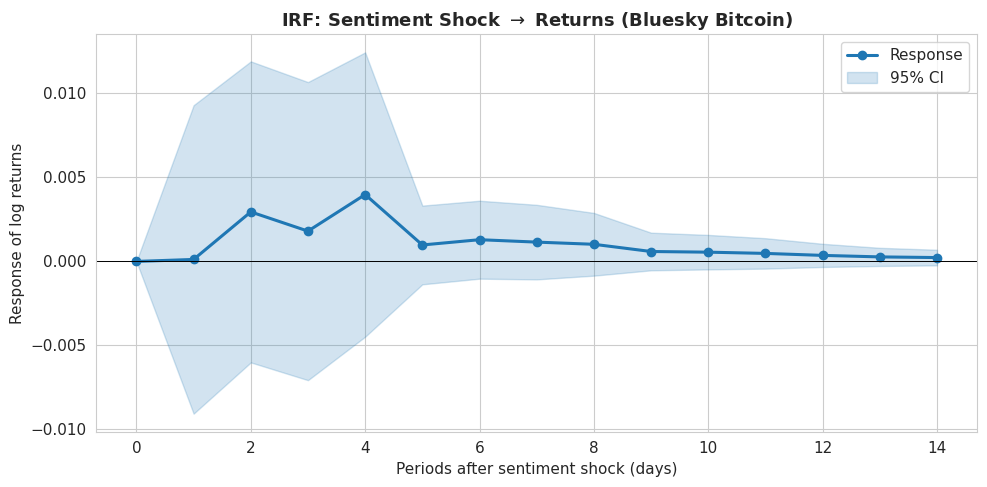

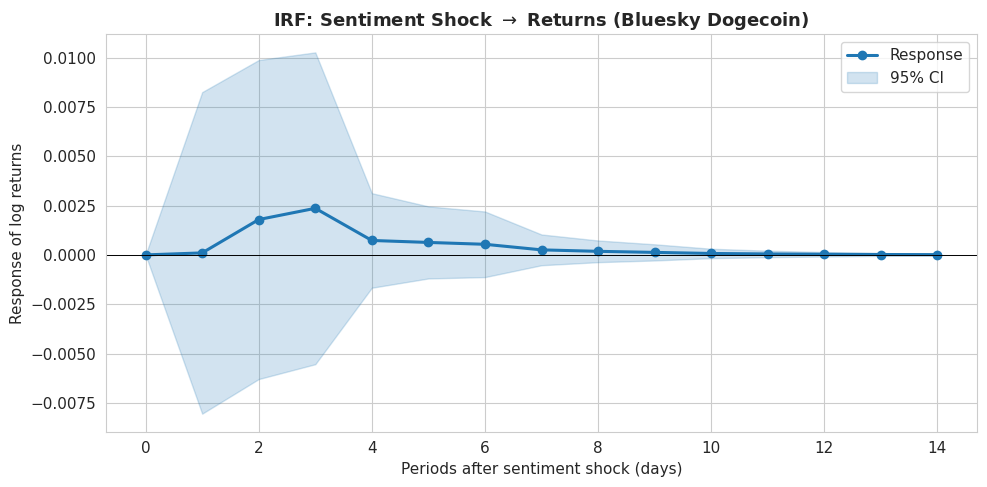

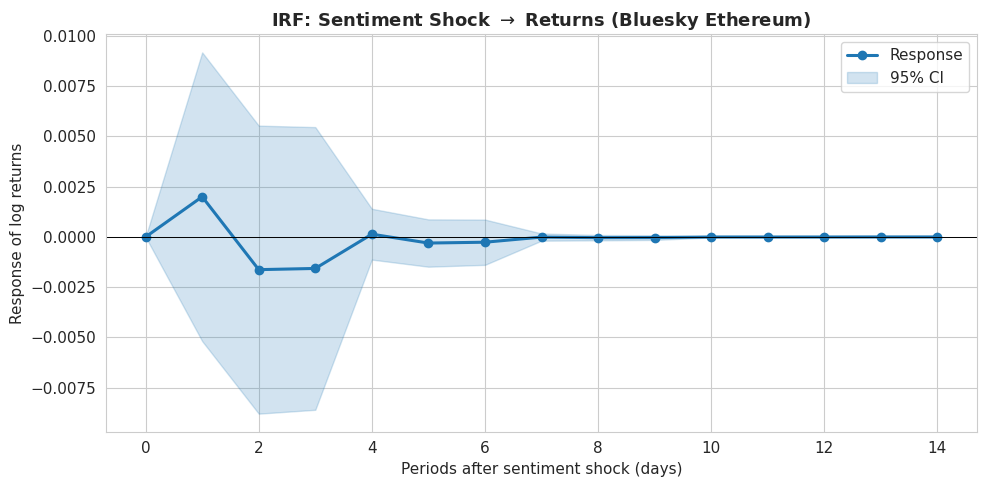

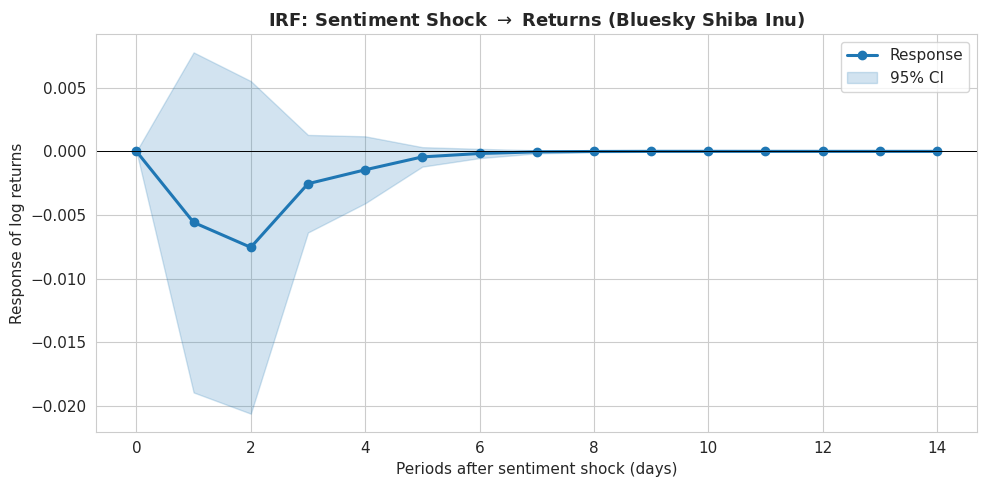

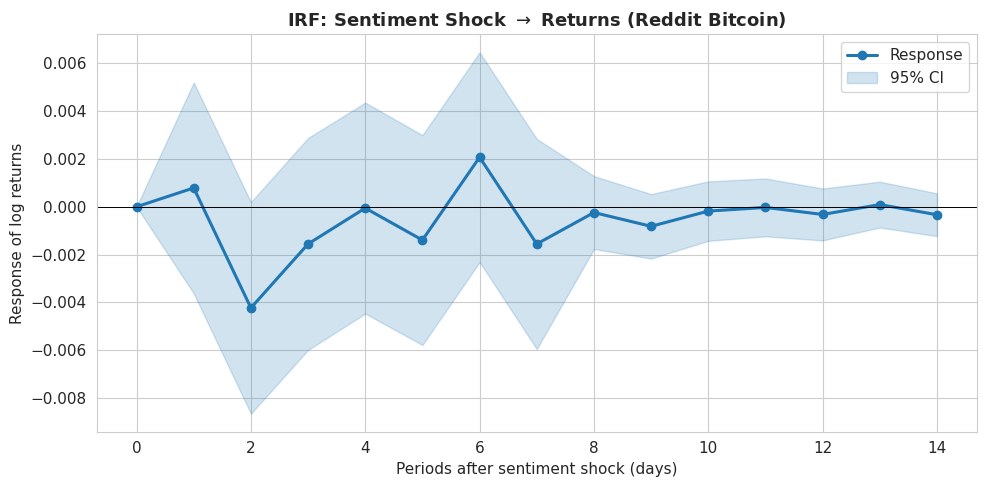

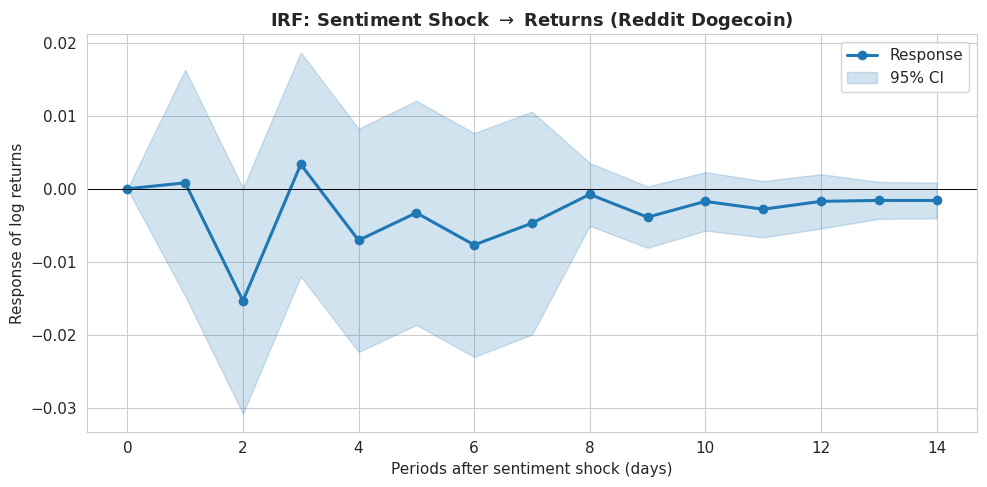

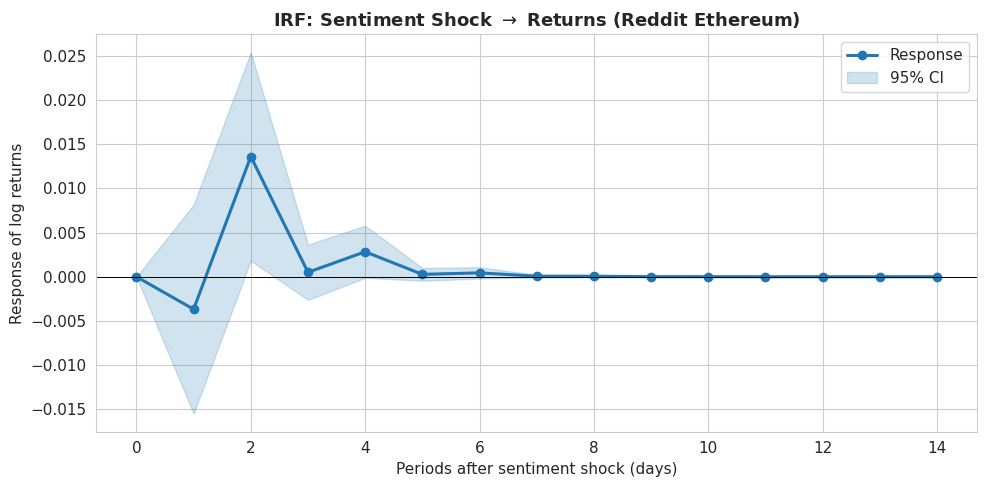

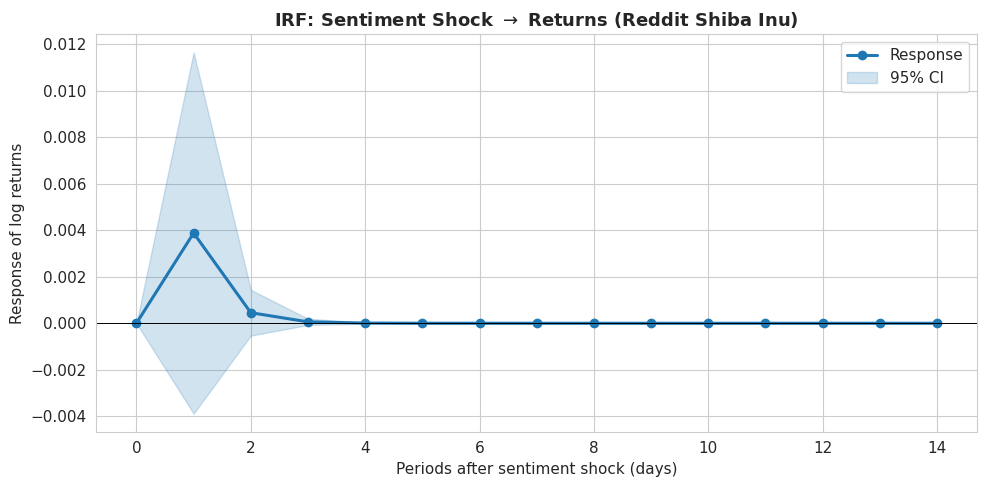

In [14]:
def plot_irf(fitted, name, save_path, periods=14):
    irf = fitted.irf(periods=periods)
    vars_ = fitted.names
    if 'sentiment_mean' not in vars_ or 'log_return' not in vars_:
        return
    s_idx, r_idx = vars_.index('sentiment_mean'), vars_.index('log_return')
    response = irf.irfs[:, r_idx, s_idx]
    try:
        se = irf.stderr()[:, r_idx, s_idx]
        lo, hi = response - 1.96 * se, response + 1.96 * se
    except Exception:
        lo = hi = None
    h = np.arange(len(response))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(h, response, color='#1f77b4', linewidth=2.2, marker='o', label='Response')
    if lo is not None:
        ax.fill_between(h, lo, hi, color='#1f77b4', alpha=0.2, label='95% CI')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_xlabel('Periods after sentiment shock (days)')
    ax.set_ylabel('Response of log returns')
    ax.set_title(f'IRF: Sentiment Shock $\\rightarrow$ Returns ({name.replace("_", " ").title()})')
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

for name, fitted in var_models.items():
    plot_irf(fitted, name, f'results/plots/09_irf_{name}.png')

# Stage 3 — Cross-Asset Transfer Entropy and Information Networks

Stage 2 examined sentiment-returns relationships *within* each asset. Stage 3 now examines whether information flows *across* assets, both within the same data type (price-to-price, sentiment-to-sentiment) and across data types (sentiment-to-price, price-to-sentiment of a different asset). This is the **information network** half of the dissertation title.

## 10. Information-Theoretic Foundations and Transfer Entropy

### Why Information Theory?
Granger causality (used in Sections 5–9) is a **linear** test. It only detects relationships that can be captured by linear regression. If the true relationship between sentiment and returns is non-linear (for example, sentiment matters only when it is extremely positive or negative), Granger causality may miss it entirely.

**Transfer entropy** is a non-parametric, non-linear analogue of Granger causality, drawn from information theory. It measures the reduction in uncertainty about the future of $Y$ provided by the past of $X$, *over and above* what the past of $Y$ already provides.

### Mathematical Foundation

The Shannon entropy of a discrete random variable $X$ measures the uncertainty associated with $X$:
$$H(X) = -\sum_x p(x) \log_2 p(x)$$

The conditional entropy of $X$ given $Y$:
$$H(X | Y) = H(X, Y) - H(Y)$$

The mutual information between $X$ and $Y$ measures how much knowing $Y$ reduces uncertainty about $X$:
$$I(X; Y) = H(X) - H(X | Y)$$

**Transfer entropy** from $X$ to $Y$ at lag $k$ is then:
$$\text{TE}_{X \rightarrow Y}^{(k)} = I(Y_t; X_{t-k} | Y_{t-k}) = H(Y_t | Y_{t-k}) - H(Y_t | Y_{t-k}, X_{t-k})$$

In words: transfer entropy quantifies the *additional* information about $Y_t$ that comes from knowing $X_{t-k}$, after accounting for what $Y_{t-k}$ already tells us. **It is asymmetric**: in general $\text{TE}_{X \rightarrow Y} \neq \text{TE}_{Y \rightarrow X}$, which is exactly what makes it suitable for causality detection.

### Estimation: Equiprobable Binning
Transfer entropy is estimated non-parametrically using histograms over discretised data. Following Aste et al. (2021), we use **equiprobable binning** (each bin contains roughly the same number of observations) rather than equal-width bins. This is shown in the literature to yield cleaner results when the true causality structure must be discovered rather than known in advance.

**Number of bins:** With $n$ observations and bivariate transfer entropy requiring a 3-dimensional histogram, the maximum sensible number of bins is roughly $n^{1/3}$. Following Aste et al., we use **5 bins** which works well for sample sizes of a few hundred observations and above.

### Significance: Shuffled-Data Z-Score
Transfer entropy itself produces a non-negative real number, but without a benchmark there is no way to know whether the value is large or small. The standard approach is to compare against a **null distribution** generated by shuffling one of the time series randomly, which destroys any causal structure while preserving the marginal distributions.

We compute the Z-score:
$$Z = \frac{\text{TE} - \langle \text{TE}_{\text{shuffled}} \rangle}{\sigma_{\text{TE}_{\text{shuffled}}}}$$

Where $\langle \text{TE}_{\text{shuffled}} \rangle$ and $\sigma_{\text{TE}_{\text{shuffled}}}$ are the mean and standard deviation of transfer entropy over 50 random shuffles. **A link is considered statistically significant if $Z > 3$**, which corresponds to roughly the 99.9th percentile of the null distribution (a very stringent threshold).

### Lag Choice
Following Aste et al., we use **lag $k = 1$** for the main analysis. This assumes the relevant information transfer happens within one period (one day for daily data, one month for monthly). Higher lags can be tested as a robustness check.

In [15]:
# --- Transfer Entropy implementation ---
# We use a custom equiprobable-binning implementation following Aste et al. (2021).
# This avoids dependency issues with PyCausality (unmaintained) while staying
# methodologically faithful to the published approach.

def equiprobable_bin(series, n_bins):
    """Discretise a series into equiprobable bins. Returns integer bin labels."""
    series = np.asarray(series, dtype=float)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(series, quantiles)
    edges[0]  -= 1e-9  # ensure leftmost point falls in bin 0
    edges[-1] += 1e-9
    return np.digitize(series, edges) - 1

def shannon_entropy(labels):
    """Empirical Shannon entropy of a sequence of discrete labels."""
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p + 1e-12))

def joint_entropy(*label_arrays):
    """Empirical joint entropy of several aligned label arrays."""
    stacked = np.column_stack(label_arrays)
    _, counts = np.unique(stacked, axis=0, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p + 1e-12))

def transfer_entropy(x, y, k=1, n_bins=5):
    """
    Compute transfer entropy from X to Y at lag k using equiprobable binning.
    Uses TE = H(Y_t, Y_{t-k}) + H(Y_{t-k}, X_{t-k}) - H(Y_{t-k}) - H(Y_t, Y_{t-k}, X_{t-k}).
    """
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    if len(x) < (n_bins ** 3) * 2 or len(x) <= k:
        return np.nan
    xb, yb = equiprobable_bin(x, n_bins), equiprobable_bin(y, n_bins)
    yt    = yb[k:]
    yt_k  = yb[:-k]
    xt_k  = xb[:-k]
    h_yt_ytk        = joint_entropy(yt, yt_k)
    h_ytk_xtk       = joint_entropy(yt_k, xt_k)
    h_ytk           = shannon_entropy(yt_k)
    h_yt_ytk_xtk    = joint_entropy(yt, yt_k, xt_k)
    return h_yt_ytk + h_ytk_xtk - h_ytk - h_yt_ytk_xtk

def transfer_entropy_zscore(x, y, k=1, n_bins=5, n_shuffles=50):
    """Compute TE plus the Z-score of TE against a shuffled null distribution."""
    te = transfer_entropy(x, y, k=k, n_bins=n_bins)
    if np.isnan(te):
        return te, np.nan
    null_te = []
    x_arr = np.asarray(x, dtype=float)
    for _ in range(n_shuffles):
        x_shuf = np.random.permutation(x_arr)
        null_te.append(transfer_entropy(x_shuf, y, k=k, n_bins=n_bins))
    null_te = np.array([v for v in null_te if not np.isnan(v)])
    if len(null_te) < 5 or null_te.std() == 0:
        return te, np.nan
    return te, (te - null_te.mean()) / null_te.std()

# Quick sanity check.
rng = np.random.default_rng(0)
x_test = rng.normal(size=400)
y_test = np.r_[0, x_test[:-1] + 0.5 * rng.normal(size=399)]  # y depends on lagged x
te_xy, z_xy = transfer_entropy_zscore(x_test, y_test)
te_yx, z_yx = transfer_entropy_zscore(y_test, x_test)
print(f'Sanity check (x -> y is the true direction):')
print(f'  TE(x -> y) = {te_xy:.4f},  Z = {z_xy:.2f}')
print(f'  TE(y -> x) = {te_yx:.4f},  Z = {z_yx:.2f}')
print(f'  Expected: TE(x -> y) > TE(y -> x), and Z(x -> y) substantially larger.')

Sanity check (x -> y is the true direction):
  TE(x -> y) = 0.9341,  Z = 32.14
  TE(y -> x) = 0.1591,  Z = -0.13
  Expected: TE(x -> y) > TE(y -> x), and Z(x -> y) substantially larger.


## 11. Cross-Asset Transfer Entropy: Building the Four Networks per Platform

**The setup:** For each platform separately (since cross-platform comparisons would conflate platform effects with asset effects), we have up to five assets (Bitcoin, Ethereum, Dogecoin, Shiba Inu, Tether). Each asset has two variables: sentiment and log return. So per platform we have up to 10 variables.

**The four directed networks computed per platform:**
1. **Price $\rightarrow$ Price (PP):** does Asset A's return predict Asset B's return?
2. **Sentiment $\rightarrow$ Sentiment (SS):** does Asset A's sentiment predict Asset B's sentiment?
3. **Sentiment $\rightarrow$ Price (SP):** does Asset A's sentiment predict Asset B's return? *(Most novel direction.)*
4. **Price $\rightarrow$ Sentiment (PS):** does Asset A's return predict Asset B's sentiment?

**For each ordered pair (A, B) within each network, compute:**
- The transfer entropy value (TE).
- The Z-score against shuffled null distribution.
- Mark as significant if Z > 3.

**Date alignment:** Each platform contributes only those dates where every asset's data is available (inner join across all assets). This ensures all transfer entropies in a platform's network are computed on the same time window.

**Implementation note:** For computational efficiency, we cache the binned versions of each series since they are reused across many pair calculations.

In [16]:
# --- Transfer Entropy parameters (adaptive to sample size) ---
TE_LAG = 1
TE_SHUFFLES = 100  # increased from 50 for more stable Z-scores
TE_SIG_Z_PRIMARY = 2.0   # primary significance threshold (95%)
TE_SIG_Z_STRONG = 3.0    # strong-evidence threshold (99.9%) for highlighting

# Bin count adapts to sample size to keep histograms well-populated.
# Rule: need at least n_bins**3 observations for a 3D joint histogram.
def choose_n_bins(n_obs):
    """Choose number of bins based on available sample size."""
    if n_obs >= 500:
        return 5  # full resolution for large samples (social media daily)
    elif n_obs >= 200:
        return 4  # medium resolution
    else:
        return 3  # coarse resolution for small samples (news monthly)

def build_platform_panel(platform_prefix, frequency='daily'):
    """
    Build a wide panel for one platform with one column per (asset, variable).
    Returns a DataFrame indexed by date with columns like 'bitcoin_sentiment',
    'bitcoin_return', 'ethereum_sentiment', 'ethereum_return', etc.
    """
    pieces = []
    for (name, freq), df in panels.items():
        if freq != frequency or not name.startswith(platform_prefix + '_'):
            continue
        asset = name.split('_', 1)[1]
        if 'log_return' not in df.columns:
            continue
        sub = df[['date', 'sentiment_mean', 'log_return']].copy()
        sub.columns = ['date', f'{asset}_sentiment', f'{asset}_return']
        pieces.append(sub.set_index('date'))
    if not pieces:
        return pd.DataFrame()
    wide = pd.concat(pieces, axis=1, join='inner').dropna()
    return wide

# Identify available platforms.
all_platforms = sorted(set(name.split('_', 1)[0] for (name, _) in panels.keys()))
print(f'Platforms available: {all_platforms}')

# For each platform, build the wide panel and report dimensions.
platform_wide_panels = {}
for plat in all_platforms:
    use_freq = 'monthly' if plat == 'news' else 'daily'
    wide = build_platform_panel(plat, frequency=use_freq)
    if wide.empty:
        print(f'  {plat}: no data at {use_freq} frequency')
        continue
    n_bins = choose_n_bins(len(wide))
    platform_wide_panels[plat] = (use_freq, wide, n_bins)
    print(f'  {plat} [{use_freq}]: {wide.shape[0]} dates x {wide.shape[1]} variables  (will use {n_bins} bins)')
    print(f'    columns: {list(wide.columns)}')

Platforms available: ['bluesky', 'news', 'reddit']
  bluesky [daily]: 391 dates x 8 variables  (will use 4 bins)
    columns: ['bitcoin_sentiment', 'bitcoin_return', 'dogecoin_sentiment', 'dogecoin_return', 'ethereum_sentiment', 'ethereum_return', 'shiba_inu_sentiment', 'shiba_inu_return']
  news [monthly]: 41 dates x 8 variables  (will use 3 bins)
    columns: ['bitcoin_sentiment', 'bitcoin_return', 'dogecoin_sentiment', 'dogecoin_return', 'ethereum_sentiment', 'ethereum_return', 'shiba_inu_sentiment', 'shiba_inu_return']
  reddit [daily]: 152 dates x 8 variables  (will use 3 bins)
    columns: ['bitcoin_sentiment', 'bitcoin_return', 'dogecoin_sentiment', 'dogecoin_return', 'ethereum_sentiment', 'ethereum_return', 'shiba_inu_sentiment', 'shiba_inu_return']


In [18]:
# Compute transfer entropy for each platform's variable pairs.
te_results_by_platform = {}

for plat, (freq, wide, n_bins) in platform_wide_panels.items():
    if wide.shape[0] < 40:
        print(f'\n  Skipping {plat}: only {wide.shape[0]} observations (need at least 40)')
        continue

    print(f'\n=== {plat.upper()} [{freq}, n={wide.shape[0]}, bins={n_bins}] ===')
    cols = list(wide.columns)
    rows = []
    n_pairs = len(cols) * (len(cols) - 1)
    pair_count = 0
    for src in cols:
        for tgt in cols:
            if src == tgt:
                continue
            pair_count += 1
            te, z = transfer_entropy_zscore(
                wide[src].values, wide[tgt].values,
                k=TE_LAG, n_bins=n_bins, n_shuffles=TE_SHUFFLES
            )
            src_asset, src_type = src.rsplit('_', 1)
            tgt_asset, tgt_type = tgt.rsplit('_', 1)
            if src_type == 'return' and tgt_type == 'return':
                network = 'PP'
            elif src_type == 'sentiment' and tgt_type == 'sentiment':
                network = 'SS'
            elif src_type == 'sentiment' and tgt_type == 'return':
                network = 'SP'
            else:
                network = 'PS'
            rows.append({
                'source': src, 'target': tgt,
                'source_asset': src_asset, 'target_asset': tgt_asset,
                'network': network,
                'TE': round(te, 5) if not np.isnan(te) else np.nan,
                'Z_score': round(z, 3) if not np.isnan(z) else np.nan,
                'sig_95pct': (not np.isnan(z)) and z > TE_SIG_Z_PRIMARY,
                'sig_strong': (not np.isnan(z)) and z > TE_SIG_Z_STRONG,
            })
    df = pd.DataFrame(rows)
    df['significant'] = df['sig_95pct']  # default significance for downstream code
    te_results_by_platform[plat] = df
    n_sig_95 = df['sig_95pct'].sum()
    n_sig_strong = df['sig_strong'].sum()
    print(f'  Computed {len(df)} pairs')
    print(f'    Significant at Z > {TE_SIG_Z_PRIMARY} (primary):  {n_sig_95}')
    print(f'    Significant at Z > {TE_SIG_Z_STRONG} (strong evidence): {n_sig_strong}')
    df.to_csv(f'results/tables/11_te_{plat}.csv', index=False)

# Combined table.
if te_results_by_platform:
    te_combined = pd.concat(
        [df.assign(platform=plat) for plat, df in te_results_by_platform.items()],
        ignore_index=True
    )
    te_combined.to_csv('results/tables/11_te_all_platforms.csv', index=False)


=== BLUESKY [daily, n=391, bins=4] ===
  Computed 56 pairs
    Significant at Z > 2.0 (primary):  6
    Significant at Z > 3.0 (strong evidence): 1

=== NEWS [monthly, n=41, bins=3] ===
  Computed 56 pairs
    Significant at Z > 2.0 (primary):  0
    Significant at Z > 3.0 (strong evidence): 0

=== REDDIT [daily, n=152, bins=3] ===
  Computed 56 pairs
    Significant at Z > 2.0 (primary):  2
    Significant at Z > 3.0 (strong evidence): 0


## 11b. Significant Transfer Entropy Links by Platform

For each platform, we now extract and summarise the statistically significant ($Z > 3$) transfer entropy links across the four networks. These are the links that survive the shuffled-data null hypothesis test and therefore reflect genuine information flows.

In [19]:
for plat, df in te_results_by_platform.items():
    print(f'\n{"=" * 70}')
    print(f'TRANSFER ENTROPY RESULTS FOR {plat.upper()}')
    print('=' * 70)

    # Strong evidence (Z > 3): the Aste-paper threshold
    strong = df[df['sig_strong']].sort_values('Z_score', ascending=False)
    primary = df[df['sig_95pct']].sort_values('Z_score', ascending=False)

    print(f'\nStrong evidence links (Z > {TE_SIG_Z_STRONG}): {len(strong)}')
    if not strong.empty:
        print(strong[['source', 'target', 'network', 'TE', 'Z_score']].to_string(index=False))

    print(f'\nPrimary significance links (Z > {TE_SIG_Z_PRIMARY}): {len(primary)}')
    if primary.empty:
        # Show top 10 sub-threshold for context
        print('  No links pass even the primary threshold. Top 10 strongest sub-threshold:')
        top10 = df.dropna(subset=['Z_score']).sort_values('Z_score', ascending=False).head(10)
        if not top10.empty:
            print(top10[['source', 'target', 'network', 'TE', 'Z_score']].to_string(index=False))
        continue

    # Break primary results down by network type
    for net in ['PP', 'SS', 'SP', 'PS']:
        sub = primary[primary['network'] == net]
        if sub.empty:
            continue
        net_label = {
            'PP': 'Price -> Price', 'SS': 'Sentiment -> Sentiment',
            'SP': 'Sentiment -> Price', 'PS': 'Price -> Sentiment'
        }[net]
        print(f'\n  {net_label}:')
        print(sub[['source', 'target', 'TE', 'Z_score']].to_string(index=False))


TRANSFER ENTROPY RESULTS FOR BLUESKY

Strong evidence links (Z > 3.0): 1
            source         target network      TE  Z_score
dogecoin_sentiment bitcoin_return      SP 0.16668     6.15

Primary significance links (Z > 2.0): 6

  Sentiment -> Sentiment:
           source              target      TE  Z_score
bitcoin_sentiment  ethereum_sentiment 0.11171    2.273
bitcoin_sentiment shiba_inu_sentiment 0.06064    2.022

  Sentiment -> Price:
            source          target      TE  Z_score
dogecoin_sentiment  bitcoin_return 0.16668    6.150
dogecoin_sentiment ethereum_return 0.12341    2.949

  Price -> Sentiment:
          source              target      TE  Z_score
shiba_inu_return shiba_inu_sentiment 0.06662    2.830
 dogecoin_return shiba_inu_sentiment 0.06334    2.345

TRANSFER ENTROPY RESULTS FOR NEWS

Strong evidence links (Z > 3.0): 0

Primary significance links (Z > 2.0): 0
  No links pass even the primary threshold. Top 10 strongest sub-threshold:

TRANSFER ENTROPY RESUL

## 12. Network Visualisation and Community Detection

**Why visualise as networks:** A list of significant pairs is hard to interpret. A directed network plot shows the entire information flow structure at a glance, with arrows indicating direction and node colours indicating community membership.

**Community detection:** We use the **Louvain algorithm** to partition the network into communities of densely-connected nodes. The Louvain algorithm maximises a quality measure called *modularity*:
$$Q = \frac{1}{2m} \sum_{ij} \left[A_{ij} - \frac{k_i k_j}{2m}\right] \delta(c_i, c_j)$$

Where $A_{ij}$ is the adjacency matrix, $k_i$ is the degree of node $i$, $m$ is total edge weight, and $\delta(c_i, c_j) = 1$ if nodes $i$ and $j$ are in the same community.

**Limitations to acknowledge:** With only 4-5 assets per platform giving roughly 8-10 nodes, community detection has limited room to find rich structure. The networks here will likely produce 2-3 communities at most. The value lies in *visualising* the information flow rather than in revealing surprising community structure.


--- BLUESKY ---


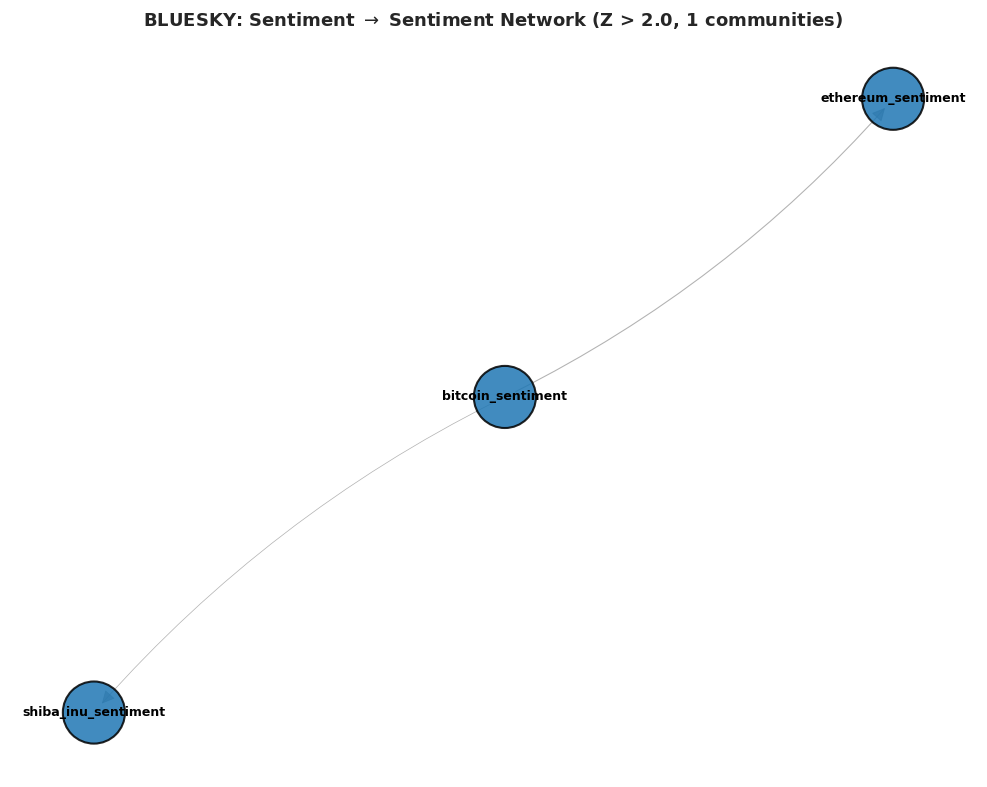

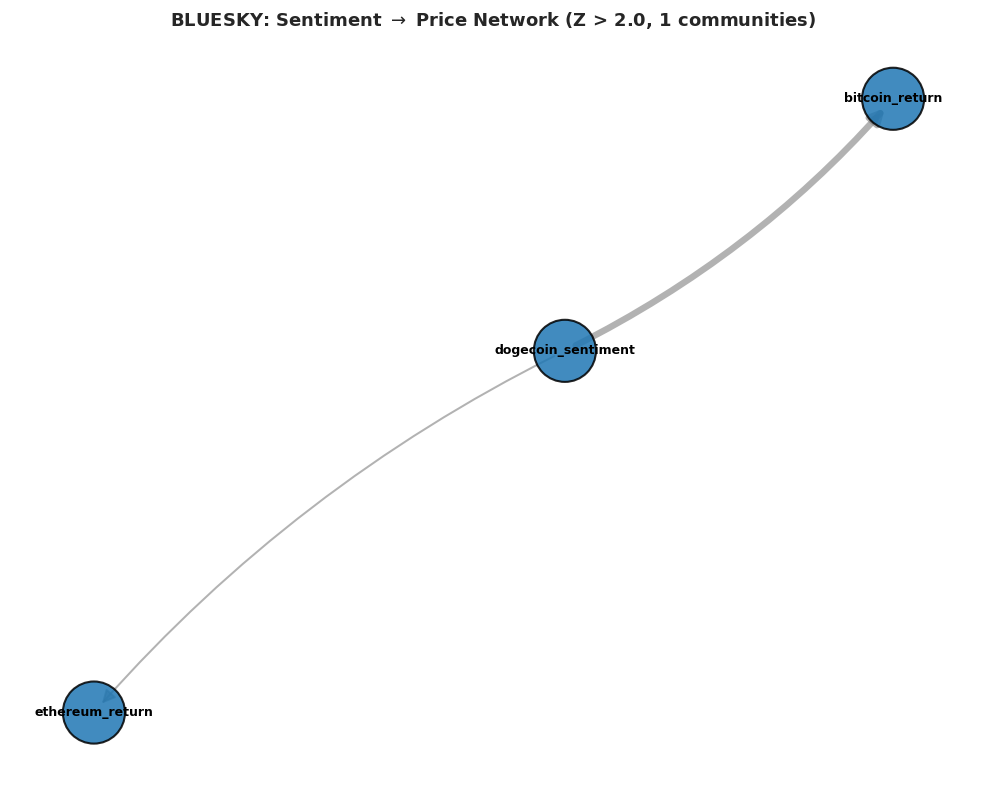

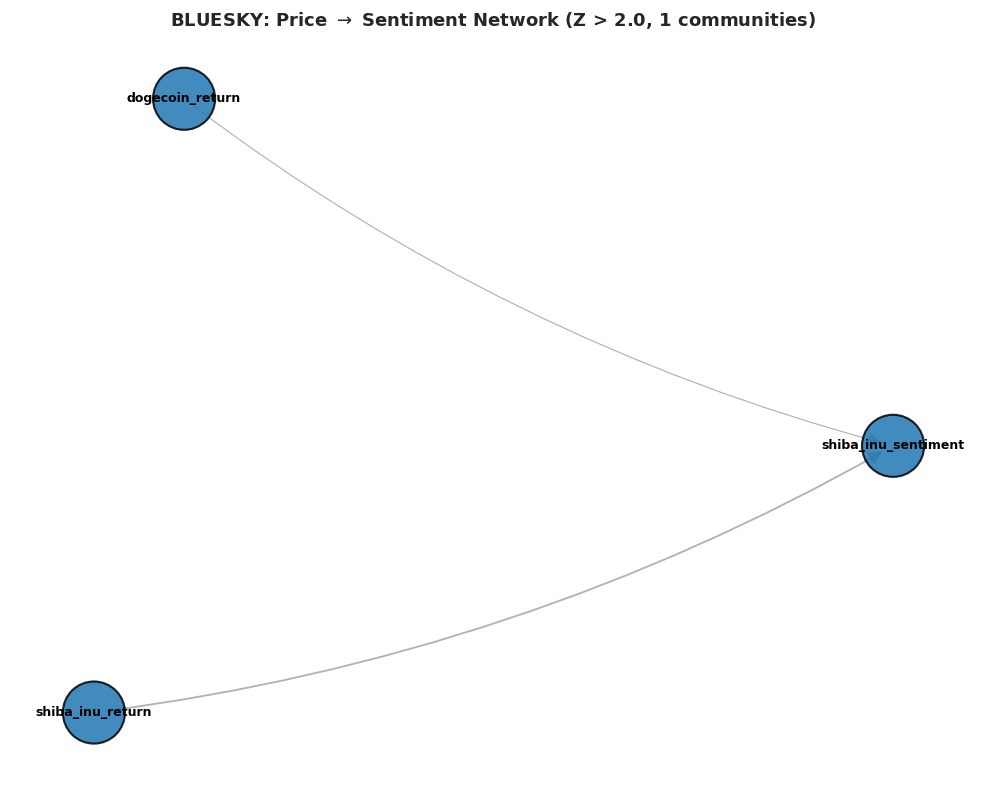

  news: no significant links to plot

--- REDDIT ---


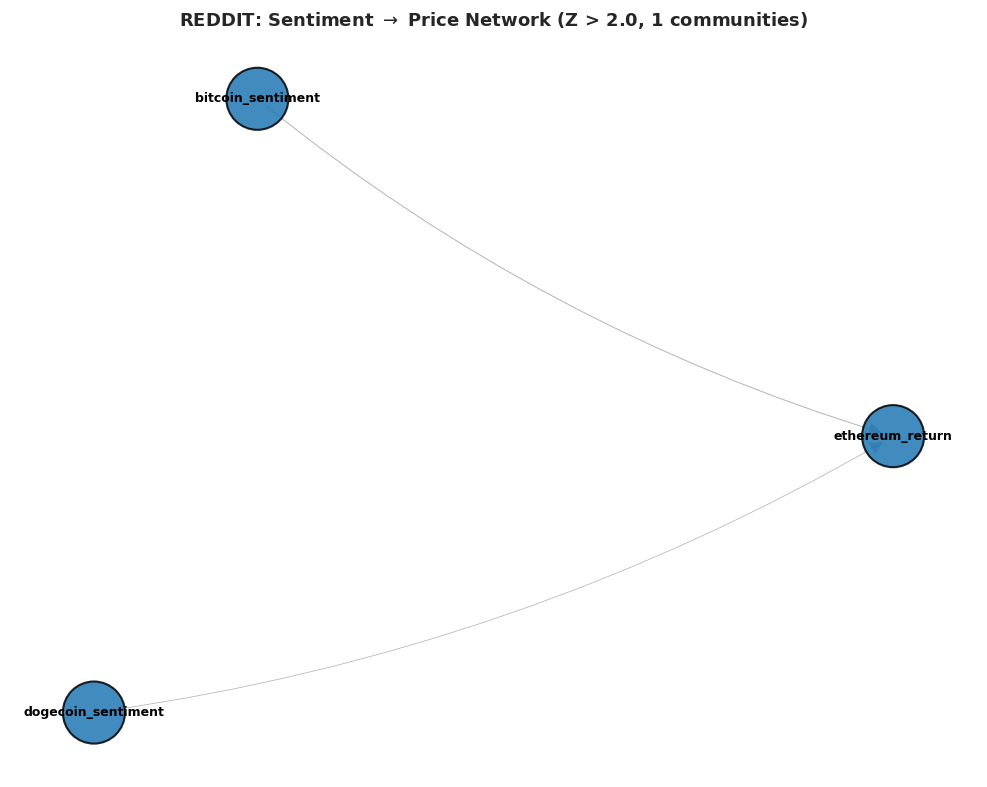


COMMUNITY DETECTION SUMMARY
platform network  n_nodes  n_communities
 bluesky      SS        3              1
 bluesky      SP        3              1
 bluesky      PS        3              1
  reddit      SP        3              1


In [20]:
def plot_te_network(df_sig, plat, network_code, save_path):
    """Plot a directed network of significant TE links."""
    sub = df_sig[df_sig['network'] == network_code]
    if sub.empty:
        return None
    G = nx.DiGraph()
    for _, row in sub.iterrows():
        G.add_edge(row['source'], row['target'],
                    weight=row['Z_score'], te=row['TE'])
    if G.number_of_edges() == 0:
        return None

    # Community detection on the undirected projection.
    G_und = G.to_undirected()
    communities = {}
    if HAS_LOUVAIN:
        try:
            communities = community_louvain.best_partition(G_und, random_state=42)
        except Exception:
            communities = {n: 0 for n in G.nodes()}
    else:
        communities = {n: 0 for n in G.nodes()}

    # Layout.
    pos = nx.spring_layout(G, k=1.2, seed=42)

    fig, ax = plt.subplots(figsize=(10, 8))

    # Colour nodes by community.
    n_communities = len(set(communities.values()))
    cmap = plt.cm.tab10
    node_colors = [cmap(communities[n] % 10) for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000,
                            alpha=0.85, edgecolors='black', linewidths=1.5, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)

    edge_widths = [0.5 + (G[u][v]['weight'] - TE_SIG_Z_PRIMARY) for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=edge_widths, arrows=True, arrowsize=20,
                            edge_color='grey', alpha=0.6, connectionstyle='arc3,rad=0.1', ax=ax)

    network_label = {
        'PP': 'Price $\\rightarrow$ Price', 'SS': 'Sentiment $\\rightarrow$ Sentiment',
        'SP': 'Sentiment $\\rightarrow$ Price', 'PS': 'Price $\\rightarrow$ Sentiment'
    }[network_code]
    ax.set_title(f'{plat.upper()}: {network_label} Network (Z > {TE_SIG_Z_PRIMARY}, {n_communities} communities)',
                  fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    return communities

community_summary = []
for plat, df in te_results_by_platform.items():
    sig_df = df[df['significant']]
    if sig_df.empty:
        print(f'  {plat}: no significant links to plot')
        continue
    print(f'\n--- {plat.upper()} ---')
    for net in ['PP', 'SS', 'SP', 'PS']:
        if not (sig_df['network'] == net).any():
            continue
        comms = plot_te_network(
            sig_df, plat, net,
            save_path=f'results/networks/{plat}_{net}_network.png'
        )
        if comms:
            community_summary.append({
                'platform': plat, 'network': net,
                'n_nodes': len(comms),
                'n_communities': len(set(comms.values())),
                'community_assignments': json.dumps(comms),
            })

community_df = pd.DataFrame(community_summary)
if not community_df.empty:
    community_df.to_csv('results/tables/12_communities.csv', index=False)
    print('\n' + '=' * 70)
    print('COMMUNITY DETECTION SUMMARY')
    print('=' * 70)
    print(community_df[['platform', 'network', 'n_nodes', 'n_communities']].to_string(index=False))

## 12b. Cross-Platform Information-Flow Summary

Aggregates the transfer entropy results across platforms to reveal which assets play the role of *information leaders* (frequently appearing as the source of significant outgoing links) versus *information followers* (frequently appearing as targets).

In [21]:
leader_rows = []
for plat, df in te_results_by_platform.items():
    sig = df[df['significant']]
    if sig.empty:
        continue
    # Out-degree = how many significant outgoing links this asset has.
    # In-degree = how many significant incoming links.
    out_counts = sig.groupby('source_asset').size()
    in_counts = sig.groupby('target_asset').size()
    all_assets = sorted(set(out_counts.index) | set(in_counts.index))
    for asset in all_assets:
        leader_rows.append({
            'platform': plat, 'asset': asset,
            'out_links': int(out_counts.get(asset, 0)),
            'in_links': int(in_counts.get(asset, 0)),
            'net_score': int(out_counts.get(asset, 0)) - int(in_counts.get(asset, 0)),
        })

leader_df = pd.DataFrame(leader_rows)
if not leader_df.empty:
    leader_df = leader_df.sort_values(['platform', 'net_score'], ascending=[True, False])
    leader_df.to_csv('results/tables/12b_information_leaders.csv', index=False)
    print('INFORMATION LEADERS vs FOLLOWERS')
    print('Positive net_score = leader (more outgoing influence).')
    print('Negative net_score = follower (more incoming influence).\n')
    for plat in leader_df['platform'].unique():
        sub = leader_df[leader_df['platform'] == plat]
        print(f'  --- {plat.upper()} ---')
        print(sub.drop('platform', axis=1).to_string(index=False))
        print()

INFORMATION LEADERS vs FOLLOWERS
Positive net_score = leader (more outgoing influence).
Negative net_score = follower (more incoming influence).

  --- BLUESKY ---
    asset  out_links  in_links  net_score
 dogecoin          3         0          3
  bitcoin          2         1          1
 ethereum          0         2         -2
shiba_inu          1         3         -2

  --- REDDIT ---
   asset  out_links  in_links  net_score
 bitcoin          1         0          1
dogecoin          1         0          1
ethereum          0         2         -2



## 13. Master Summary Workbook and Final Export

Consolidates everything into one Excel workbook with clearly labelled sheets, and packages all plots and tables into a downloadable ZIP.

In [22]:
# Build per-panel master summary that captures the headline findings at the optimal lag.
master_rows = []
for (name, freq), merged in panels.items():
    asset = name.split('_', 1)[1] if '_' in name else name
    row = {
        'panel': name, 'frequency': freq,
        'n_obs': len(merged),
        'optimal_lag': optimal_lags.get((name, freq)),
    }
    if 'log_return' in merged.columns:
        v = merged[['sentiment_mean', 'log_return']].dropna()
        if len(v) >= 12:
            r, p = stats.pearsonr(v['sentiment_mean'], v['log_return'])
            row['contemp_pearson_r'] = round(r, 4)
            row['contemp_pearson_p'] = round(p, 4)
    if not granger_headline_df.empty:
        sub = granger_headline_df[(granger_headline_df['panel'] == name) &
                                    (granger_headline_df['frequency'] == freq)]
        s2r = sub[sub['direction'] == 'sentiment -> returns']
        if not s2r.empty:
            row['granger_s2r_p'] = float(s2r['p_value'].iloc[0])
            row['granger_s2r_sig'] = bool(s2r['significant_5pct'].iloc[0])
        r2s = sub[sub['direction'] == 'returns -> sentiment']
        if not r2s.empty:
            row['granger_r2s_p'] = float(r2s['p_value'].iloc[0])
            row['granger_r2s_sig'] = bool(r2s['significant_5pct'].iloc[0])
    # Best-lag Granger (from full scan).
    if not granger_best_df.empty:
        sub = granger_best_df[(granger_best_df['panel'] == name) &
                                (granger_best_df['frequency'] == freq)]
        s2r = sub[sub['direction'] == 'sentiment -> returns']
        if not s2r.empty:
            row['granger_s2r_best_lag'] = int(s2r['best_lag'].iloc[0])
            row['granger_s2r_best_p'] = float(s2r['best_p_value'].iloc[0])
            row['granger_s2r_best_sig'] = bool(s2r['best_significant'].iloc[0])
        r2s = sub[sub['direction'] == 'returns -> sentiment']
        if not r2s.empty:
            row['granger_r2s_best_lag'] = int(r2s['best_lag'].iloc[0])
            row['granger_r2s_best_p'] = float(r2s['best_p_value'].iloc[0])
            row['granger_r2s_best_sig'] = bool(r2s['best_significant'].iloc[0])
    if not ror_df.empty:
        sub = ror_df[(ror_df['asset'] == asset) & (ror_df['frequency'] == freq)]
        if not sub.empty:
            best = sub.loc[sub['p_value'].idxmin()]
            row['ror_best_p'] = float(best['p_value'])
            row['ror_pattern'] = best['pattern']
    if freq == 'daily' and name in var_models:
        row['var_aic'] = round(var_models[name].aic, 3)
    master_rows.append(row)

master_df = pd.DataFrame(master_rows).sort_values(['panel', 'frequency'])

OUTPUT = 'results/tables/comprehensive_results.xlsx'
with pd.ExcelWriter(OUTPUT, engine='openpyxl') as writer:
    master_df.to_excel(writer, sheet_name='1_Master_Summary', index=False)
    optimal_lag_df.to_excel(writer, sheet_name='2_Optimal_Lags', index=False)
    if not adf_df.empty:
        adf_df.to_excel(writer, sheet_name='3_ADF_Stationarity', index=False)
    if not correlation_df.empty:
        correlation_df.to_excel(writer, sheet_name='4_Correlations', index=False)
    if not granger_headline_df.empty:
        granger_headline_df.to_excel(writer, sheet_name='5_Granger_Headline', index=False)
    if not granger_scan_df.empty:
        granger_scan_df.to_excel(writer, sheet_name='6a_Granger_FullScan', index=False)
    if not granger_best_df.empty:
        granger_best_df.to_excel(writer, sheet_name='6b_Granger_BestLag', index=False)
    # Best-lag Granger (from full scan).
    if not granger_best_df.empty:
        sub = granger_best_df[(granger_best_df['panel'] == name) &
                                (granger_best_df['frequency'] == freq)]
        s2r = sub[sub['direction'] == 'sentiment -> returns']
        if not s2r.empty:
            row['granger_s2r_best_lag'] = int(s2r['best_lag'].iloc[0])
            row['granger_s2r_best_p'] = float(s2r['best_p_value'].iloc[0])
            row['granger_s2r_best_sig'] = bool(s2r['best_significant'].iloc[0])
        r2s = sub[sub['direction'] == 'returns -> sentiment']
        if not r2s.empty:
            row['granger_r2s_best_lag'] = int(r2s['best_lag'].iloc[0])
            row['granger_r2s_best_p'] = float(r2s['best_p_value'].iloc[0])
            row['granger_r2s_best_sig'] = bool(r2s['best_significant'].iloc[0])
    if not ror_df.empty:
        ror_df.to_excel(writer, sheet_name='7_Returns_on_Returns', index=False)
    if not var_summary_df.empty:
        var_summary_df.to_excel(writer, sheet_name='8_VAR_Summary', index=False)
    if te_results_by_platform:
        te_combined = pd.concat([df.assign(platform=p) for p, df in te_results_by_platform.items()],
                                 ignore_index=True)
        te_combined.to_excel(writer, sheet_name='9_TransferEntropy_All', index=False)
        sig_only = te_combined[te_combined['significant']]
        if not sig_only.empty:
            sig_only.to_excel(writer, sheet_name='10_TE_Significant', index=False)
    if not leader_df.empty:
        leader_df.to_excel(writer, sheet_name='11_Information_Leaders', index=False)

print(f'Master workbook saved: {OUTPUT}')
print('\nSheets in workbook:')
xl = pd.ExcelFile(OUTPUT)
for s in xl.sheet_names:
    print(f'  {s}')

print('\n=== MASTER SUMMARY (headline findings per panel) ===')
print(master_df.to_string(index=False))

Master workbook saved: results/tables/comprehensive_results.xlsx

Sheets in workbook:
  1_Master_Summary
  2_Optimal_Lags
  3_ADF_Stationarity
  4_Correlations
  5_Granger_Headline
  6a_Granger_FullScan
  6b_Granger_BestLag
  7_Returns_on_Returns
  8_VAR_Summary
  9_TransferEntropy_All
  10_TE_Significant
  11_Information_Leaders

=== MASTER SUMMARY (headline findings per panel) ===
            panel frequency  n_obs  optimal_lag  contemp_pearson_r  contemp_pearson_p  granger_s2r_p  granger_s2r_sig  granger_r2s_p  granger_r2s_sig  granger_s2r_best_lag  granger_s2r_best_p granger_s2r_best_sig  granger_r2s_best_lag  granger_r2s_best_p granger_r2s_best_sig  ror_best_p    ror_pattern  var_aic
  bluesky_bitcoin     daily    607            4             0.1708             0.0000         0.8250            False         0.0000             True                   7.0              0.3263                False                   1.0              0.0000                 True      0.0773    random walk

In [23]:
shutil.make_archive('comprehensive_results', 'zip', 'results')
size_mb = os.path.getsize('comprehensive_results.zip') / 1e6
print(f'Archive: comprehensive_results.zip ({size_mb:.2f} MB)')
files.download('comprehensive_results.zip')

Archive: comprehensive_results.zip (4.49 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>